In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

In [2]:
from functools import partial
from typing import Any, Sequence

# activate TPUs if available
try:
    import jax.tools.colab_tpu
    jax.tools.colab_tpu.setup_tpu()
except (KeyError, RuntimeError):
    print("TPU not found, continuing without it.")

from jax import config
config.update("jax_enable_x64", True)

import jax
from jax import numpy as jnp
from jax import random
from jax import vmap
from jax.tree_util import Partial, tree_map

from jaxopt import LBFGS, GradientDescent
from jaxopt import linear_solve
from jaxopt import OptaxSolver
from jaxopt import tree_util

import optax

# we use flax to construct a small multi-layer perceptron
from flax import linen as nn
from tqdm.auto import tqdm

# for plotting
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

TPU not found, continuing without it.


In [3]:
# import scienceplots
# plt.style.use(["science", "grid"])
%matplotlib inline

# Default setting
import matplotlib as mpl
import matplotlib
# import seaborn as sns
from matplotlib import cm
from cycler import cycler

# mpl.rcParams['axes.prop_cycle'] = cycler(color='brgcmyk')
# grid setting
plt.rcParams['axes.grid'] = False
plt.rcParams['grid.color'] = '#808080'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

# graph font size
# mpl.rcParams['font.size'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['figure.titlesize'] = 18
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14

# tight axis
plt.rcParams['axes.xmargin'] = 0

# figure size
plt.rcParams["figure.figsize"] = (6.4, 4.8)

# LaTeX
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'


In [4]:
import pickle
import time
from jax import hessian, jacobian, jit, vmap, grad, random, value_and_grad
from functools import partial
import diffrax
from typing import Callable, Optional, Union
from flax import linen as nn
from flax.training.train_state import TrainState
import optax
from jax_md.quantity import force
import equinox as eqx
from tqdm import trange, tqdm

In [5]:
import sys
sys.path.append('/home/kna35/GaTech Dropbox/Kyungmi Na/physical-intelligence-change')

In [6]:
from blockymetamaterials.utils import SolutionType, SolutionData, ControlParams, GeometricalParams, MechanicalParams, LigamentParams, ContactParams
# from blockymetamaterials.geometry import Geometry, QuadGeometry, compute_inertia, compute_edge_angles, compute_edge_lengths, DOFsInfo, QuadGeometry_Circle_InputSource, polygon_area, polygon_polar_moment
from blockymetamaterials.geometry import Geometry, QuadGeometry, compute_inertia, compute_edge_angles, compute_edge_lengths, DOFsInfo, QuadGeometry_Circle_InputSource, QuadGeometry_Circle_InputSource_vis, polygon_area, polygon_polar_moment
from blockymetamaterials.energy import build_strain_energy, kinetic_energy, ligament_energy, ligament_energy_linearized, build_contact_energy, combine_block_energies, compute_ligament_strains_history, constrain_energy
from typing import Any, Literal, Optional, List, Union, Tuple, Dict
import dataclasses
from dataclasses import dataclass
from itertools import combinations
from cooptimization import setup_dynamic_solver, setup_dynamic_solver_all


In [7]:

class minmax_scaler():
  def __init__(self, input_data, output_data):
    # assume that 
    self.data_max = jnp.max(input_data, axis=(0, 1), keepdims=True)
    self.data_min = jnp.min(input_data, axis=(0, 1), keepdims=True)
    print(self.data_max.shape, self.data_min.shape)

    self.output_data_max = jnp.max(output_data, axis=(0, 1), keepdims=True)
    self.output_data_min = jnp.min(output_data, axis=(0, 1), keepdims=True)
    print(self.output_data_max.shape, self.output_data_min.shape)

  def transform(self, input_data, output_data):
    data_normalized = 2.0 * ( input_data - self.data_min ) / ( self.data_max - self.data_min ) - 1.0  # Add a small value to avoid division by zero
    output_normalized = (output_data - self.output_data_min) / (self.output_data_max - self.output_data_min)
    return data_normalized, output_normalized
  
  def inverse_transform(self, data_normalized, output_normalized):
    data_original = (data_normalized + 1.0) * (self.data_max - self.data_min) / 2.0 + self.data_min
    output_original = output_normalized * (self.output_data_max - self.output_data_min) + self.output_data_min
    return data_original, output_original

  def information(self):
    print("data min : ", self.data_min)
    print("data max : ", self.data_max)
    print("test data min : ", self.output_data_min)
    print("test data max : ", self.output_data_max)
    return self.data_min, self.data_max, self.output_data_min, self.output_data_max

class TimeSeriesCNN(nn.Module):
    features: int = 64
    output_features: int = 2

    @nn.compact
    def __call__(self, x):
        # Input shape: (batch_size, time_steps, 2)
        x = nn.Conv(self.features, kernel_size=(3,), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.Conv(self.features, kernel_size=(3,), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.Conv(self.output_features, kernel_size=(1,), padding='SAME')(x)  # Final output: 2 channels
        return x  # Shape: (batch_size, time_steps, 2)
    

## Simulation

In [8]:
n1_blocks = 25
n2_blocks = 25
n_piece = 8
n_source = n_piece * 2
spacing = 15. + 0.075*15.  # 1.0  # 15 mm
hinge_length = 0.075*15.  # Same as bond length
initial_angle = 25.0*jnp.pi/180

horizontal_shifts, vertical_shifts = QuadGeometry_Circle_InputSource(n1_blocks, n2_blocks, spacing=spacing, bond_length=hinge_length, n_piece=n_piece).get_design_from_rotated_square(
    angle=initial_angle,
)  # Initial design

# use previous parameters
# Mechanical params
k_stretch = 4.00  # stretching stiffness 120. N/mm
k_shear = k_stretch * 2.1e-01 # shearing stiffness 1.19 N/mm
k_rot = k_stretch * 2.6902e-03 * 20.0 # rotational stiffness 1.50 Nmm

density = 3.2325226e-08 # 0.03859661 * 1e-6  # Mg/mm^2


# Dynamic loading (I don't use these parameters)----------
amplitude = 0.5 * spacing  # 0.5 * spacing default 
loading_rate = 30.0 # jnp.array([30., 0., 20., 20., 20.])  #  Hz loading frequency for dynamic input
input_delay = 0.1*30.0**-1 * jnp.ones((n1_blocks,))
#---------------------------------------------------------
min_angle=-15*jnp.pi/180
cutoff_angle=-10*jnp.pi/180

simulation_time = 1.0
n_timepoints = 200
bond_length = hinge_length
linearized_strains = False
use_contact = False
k_contact = k_rot

geometry = QuadGeometry_Circle_InputSource(
    n1_blocks=n1_blocks,
    n2_blocks=n2_blocks,
    spacing=spacing,
    bond_length=bond_length,
    n_piece=n_piece
)

block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors = geometry.get_parametrization()
_bond_connectivity = bond_connectivity()  # Compute bond connectivity once as it is constant
_reference_bond_vectors = reference_bond_vectors(horizontal_shifts, vertical_shifts)  # Compute reference bond vectors once as they are constant

k_stretch_arr = k_stretch * jnp.ones((_bond_connectivity.shape[0],))  # stretching stiffness 120. N/mm
k_shear_arr = k_shear * jnp.ones((_bond_connectivity.shape[0],)) # shearing stiffness 1.19 N/mm
k_rot_arr = k_rot * jnp.ones((_bond_connectivity.shape[0],)) # rotational stiffness 1.50 Nmm

# NOTE: Damping is assumed to be the same for all blocks as it is small enough that the inertia change during optimization is negligible.
# The reference is taken to be zero angle rotated square geometry.
# 0.36125, 0.02175026 = mass and inertia of a single square of zero angle and unitary spacing and density and 0.15 bond length.
dampall = 0.624118 
dampxy = 0.884512
damprot = 0.85392

damping_params = jnp.array([dampall * 0.186, dampxy * 0.36125, damprot * 0.02175026])
print( "initial damping params : ", damping_params )
damping = damping_params[0] * jnp.array([
    2 * (damping_params[1] * density * spacing**2 * k_shear)**0.5,
    2 * (damping_params[1] * density * spacing**2 * k_shear)**0.5,
    2 * (damping_params[2] * density * spacing**4 * k_rot)**0.5
]) * jnp.ones((geometry.n_blocks, 3))

# Damping
damped_blocks = jnp.arange(geometry.n_blocks)

n_excited_blocks = geometry.n_piece
idx_input_source = jnp.arange(geometry.n_quads,geometry.n_quads+n_excited_blocks)
driven_block_DOF_pairs = jnp.array([
    jnp.tile(
        idx_input_source,
        2),
    jnp.array([0]*n_excited_blocks + [1]*n_excited_blocks)
]).T
print("driven_block_DOF_pairs", driven_block_DOF_pairs)


# block_to_inner = -jnp.ones(geometry.n1_blocks * geometry.n2_blocks, dtype=int)
# block_to_inner = block_to_inner.at[geometry.blocks_inside].set(jnp.arange(len(geometry.blocks_inside)))

# clamped_idx = block_to_inner[ (geometry.n1_blocks*geometry.n2_blocks)//2 ]
# print("clamped idx : ", clamped_idx)
# n_clamped_blocks = 1
# clamped_block_DOF_pairs = jnp.array([
#     jnp.tile(
#         jnp.array([clamped_idx]),
#         3),
#     jnp.array([0]*n_clamped_blocks + [1]*n_clamped_blocks + [2]*n_clamped_blocks)
# ]).T


# constrained_block_DOF_pairs = jnp.concatenate(
#     [clamped_block_DOF_pairs]
# )

constrained_block_DOF_pairs = jnp.zeros((0,2), dtype=int)

# clamped_blocks_ids = jnp.unique(
#     jnp.concatenate([
#         clamped_block_DOF_pairs
#     ])[:, 0]
# )

driven_blocks_ids = jnp.unique( driven_block_DOF_pairs[:, 0] )
constrained_DOFs_loading_vector = jnp.zeros((len(constrained_block_DOF_pairs),))

allowed_blocks = jnp.arange( geometry.n_quads+n_excited_blocks )
moving_blocks_ids = allowed_blocks
# moving_blocks_ids = jnp.delete( allowed_blocks, clamped_blocks_ids ) # or jnp.delete( jnp.arange(geometry.n_blocks), constrained_blocks_ids )

loaded_DOF_ids = jnp.array([block_id * 3 + DOF_id for block_id, DOF_id in driven_block_DOF_pairs])

def pulse(t, amplitude, loading_rate):
    return amplitude * jnp.where(
        (t > 0.) & (t < loading_rate**-1),
        (1 - jnp.cos(2*jnp.pi * loading_rate * t))/2,
        0.
    )
    
excited_blocks_fn = None

if excited_blocks_fn is None:
    # Apply sinthetic pulse loading
    # NOTE: This is used for optimization.
    def constrained_DOFs_fn(t, amplitude, loading_rate, input_delay):
        return 0.0 * constrained_DOFs_loading_vector
else:
    # Apply user-defined loading
    # NOTE: This can be used to apply the experimental loading
    def constrained_DOFs_fn(t, **kwargs):
        return excited_blocks_fn(t) * constrained_DOFs_loading_vector
    
# Construct strain energy
strain_energy = build_strain_energy(
    bond_connectivity=_bond_connectivity,
    bond_energy_fn=ligament_energy_linearized if linearized_strains else ligament_energy,
)
contact_energy = build_contact_energy(bond_connectivity=_bond_connectivity)
potential_energy = combine_block_energies(strain_energy, contact_energy) if use_contact else strain_energy

atol = 1e-4
rtol = 1e-4

free_DOF_ids, constrained_DOF_ids, all_DOF_ids = DOFsInfo(geometry.n_blocks, constrained_block_DOF_pairs)
damped_DOF_ids = jnp.concatenate([jnp.arange(block_id * 3, (block_id + 1) * 3) for block_id in damped_blocks])

target_size = (1, 1)
target_shift = (0, 0)
ts = jnp.linspace(0, simulation_time, n_timepoints)

target_blocks = jnp.array([
    j * n1_blocks + i
    for i in range((n1_blocks-target_size[0])//2 + target_shift[0], (n1_blocks+target_size[0])//2 + target_shift[0])
    for j in range((n2_blocks-target_size[1])//2 + target_shift[1], (n2_blocks+target_size[1])//2 + target_shift[1])
])

vertices = centroid_node_vectors(horizontal_shifts, vertical_shifts)
areas = jnp.stack([ polygon_area(vertice) for vertice in vertices ], axis=0)
area_moments = jnp.stack([ polygon_polar_moment(vertice) for vertice in vertices ], axis=0)

density_arr = jnp.ones( (len(areas)) ) * density
density_arr = density_arr.at[geometry.n_quads:].set(2.0 * density) # shell blocks are heavier than inner blocks
# target_blocks = 48
# density_arr = density_arr.at[target_blocks].set( density + 0.007301278265064265 * 1e-6  )

translational_inertia = density_arr * areas
rotational_inertia = density_arr * area_moments

# translational_inertia = density * areas
# rotational_inertia = density * area_moments

_inertia = jnp.column_stack((translational_inertia, translational_inertia, rotational_inertia))

@eqx.filter_jit
def forward_problem(inputs, output_data, free_DOF_ids, constrained_DOF_ids, all_DOF_ids):
    
    # Analysis params
    timepoints = jnp.linspace(0.0, simulation_time, n_timepoints)
    horizontal_shifts, vertical_shifts = inputs

    def loading_fn(state, t, **kwargs):
        return vmap(jnp.interp, in_axes=(None,None,1))( t, timepoints, output_data )

    # Setup solver
    solve_dynamics = setup_dynamic_solver_all(
        geometry=geometry,
        energy_fn=potential_energy,
        # add new arguments
        loaded_DOF_ids=loaded_DOF_ids,
        loading_fn=loading_fn,
        constrained_block_DOF_pairs=constrained_block_DOF_pairs,
        constrained_DOFs_fn=constrained_DOFs_fn,
        damped_DOF_ids=damped_DOF_ids,
        free_DOF_ids=free_DOF_ids,
        constrained_DOF_ids=constrained_DOF_ids,
        all_DOF_ids=all_DOF_ids,
        atol=atol,
        rtol=rtol,
    )

    # Define control params
    control_params = ControlParams(
        geometrical_params=GeometricalParams(
            block_centroids=block_centroids(horizontal_shifts, vertical_shifts),
            centroid_node_vectors=centroid_node_vectors(horizontal_shifts, vertical_shifts),
        ),
        mechanical_params=MechanicalParams(
            bond_params=LigamentParams(
                k_stretch=k_stretch_arr,
                k_shear=k_shear_arr,
                k_rot=k_rot_arr,
                reference_vector=_reference_bond_vectors,
            ),
            density=density,
            damping=damping,
            contact_params=ContactParams(
                k_contact=k_contact,
                min_angle=min_angle,
                cutoff_angle=cutoff_angle,
            ),
            inertia=_inertia
        ),
        constraint_params=dict( # I don't use this parameter
            amplitude=amplitude,
            loading_rate=loading_rate,
            input_delay=input_delay,
        ),
        loading_params=dict( # I don't use this parameter
            amplitude=amplitude,
            loading_rate=loading_rate,
            input_delay=input_delay,
        ),
    )

    # Initial conditions
    # state0 = jnp.zeros((2, geometry.n_blocks, 3))
    state0 = 1e-10 * jnp.ones((2, geometry.n_blocks, 3))

    start = time.time()
    # Solve dynamics
    solution = solve_dynamics(
        state0=state0,
        timepoints=timepoints,
        control_params=control_params,
    )
    print("duration : ", time.time() - start)
    
    return solution

initial damping params :  [0.11608595 0.31952996 0.01857298]
driven_block_DOF_pairs [[293   0]
 [294   0]
 [295   0]
 [296   0]
 [297   0]
 [298   0]
 [299   0]
 [300   0]
 [293   1]
 [294   1]
 [295   1]
 [296   1]
 [297   1]
 [298   1]
 [299   1]
 [300   1]]


In [9]:
horizontal_shifts.shape, vertical_shifts.shape

((26, 25, 2), (25, 26, 2))

In [ ]:
n1_blocks = 27
n2_blocks = 27
n_piece = 8
n_source = n_piece * 2
spacing = 15. + 0.075*15.  # 1.0  # 15 mm
hinge_length = 0.075*15.  # Same as bond length
bond_length = hinge_length
initial_angle = 25.0*jnp.pi/180

horizontal_shifts, vertical_shifts = QuadGeometry_Circle_InputSource(n1_blocks, n2_blocks, spacing=spacing, bond_length=hinge_length, n_piece=n_piece).get_design_from_rotated_square(
    angle=initial_angle,
)  # Initial design


geometry = QuadGeometry_Circle_InputSource(
    n1_blocks=n1_blocks,
    n2_blocks=n2_blocks,
    spacing=spacing,
    bond_length=bond_length,
    n_piece=n_piece
)

block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors = geometry.get_parametrization()
_bond_connectivity = bond_connectivity()  # Compute bond connectivity once as it is constant
_reference_bond_vectors = reference_bond_vectors(horizontal_shifts, vertical_shifts)  # Compute reference bond vectors once as they are constant

NameError: name 'bond_length' is not defined

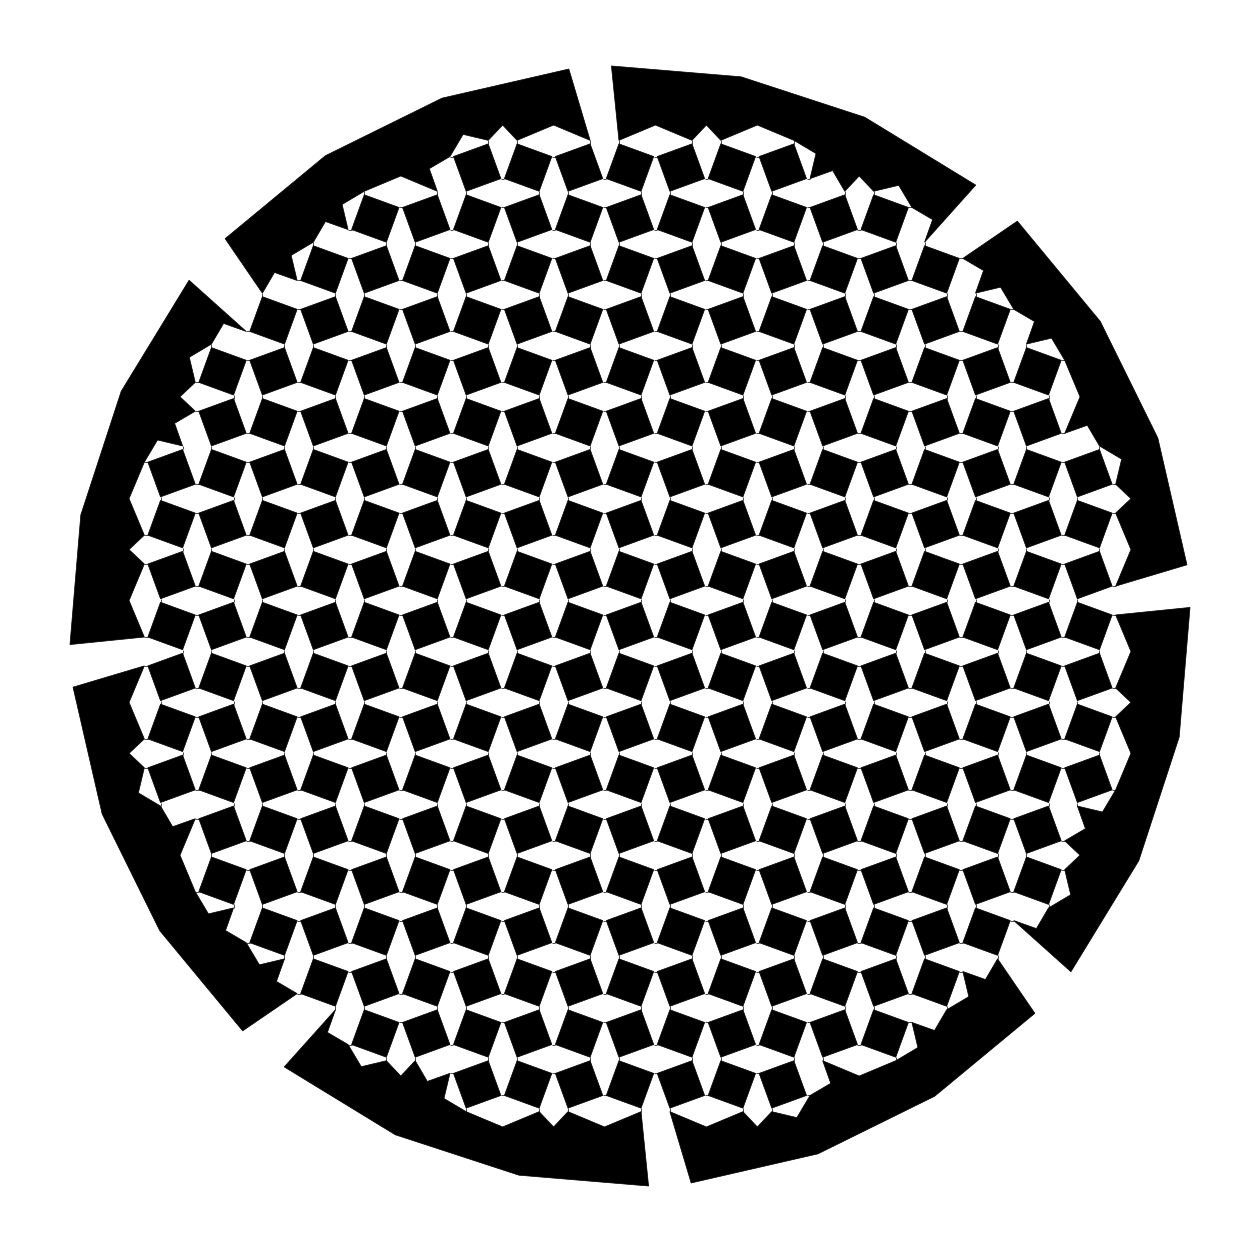

In [10]:
from blockymetamaterials.plotting_input import plot_geometry, compute_xy_limits

# generate animation
design_values = (horizontal_shifts, vertical_shifts)
block_centroids_temp = block_centroids(horizontal_shifts, vertical_shifts)
centroid_node_vectors_temp = centroid_node_vectors(horizontal_shifts, vertical_shifts)

shell_verts = jnp.concatenate([ centroids + vertices for centroids, vertices in zip(block_centroids_temp, centroid_node_vectors_temp)], axis=0)
xlim, ylim = compute_xy_limits(
    shell_verts) + 0.5*geometry.spacing * jnp.array([-1, 1])

fig, ax = plt.subplots(figsize=(16,16))
block_idx = jnp.concatenate( (geometry.blocks_inside, jnp.arange(geometry.n_quads, geometry.n_quads+geometry.n_piece)), dtype=int  )
colors = 'k'
plot_geometry(block_centroids_temp,
              centroid_node_vectors_temp,
              _bond_connectivity,
              color=colors, ax=ax)
ax.axis("equal")
ax.axis("off")
plt.show()

## New input and training neural network

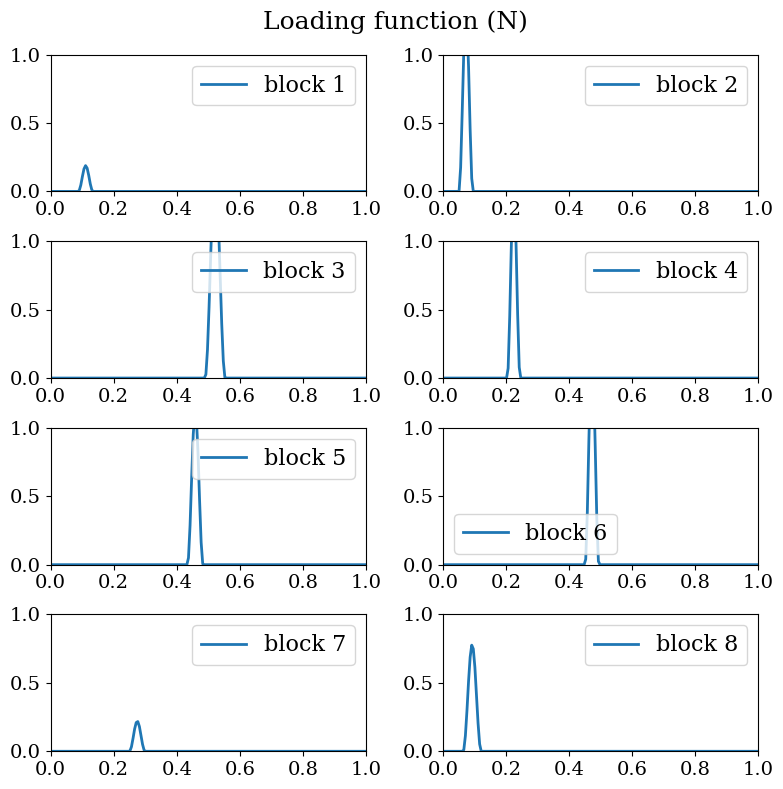

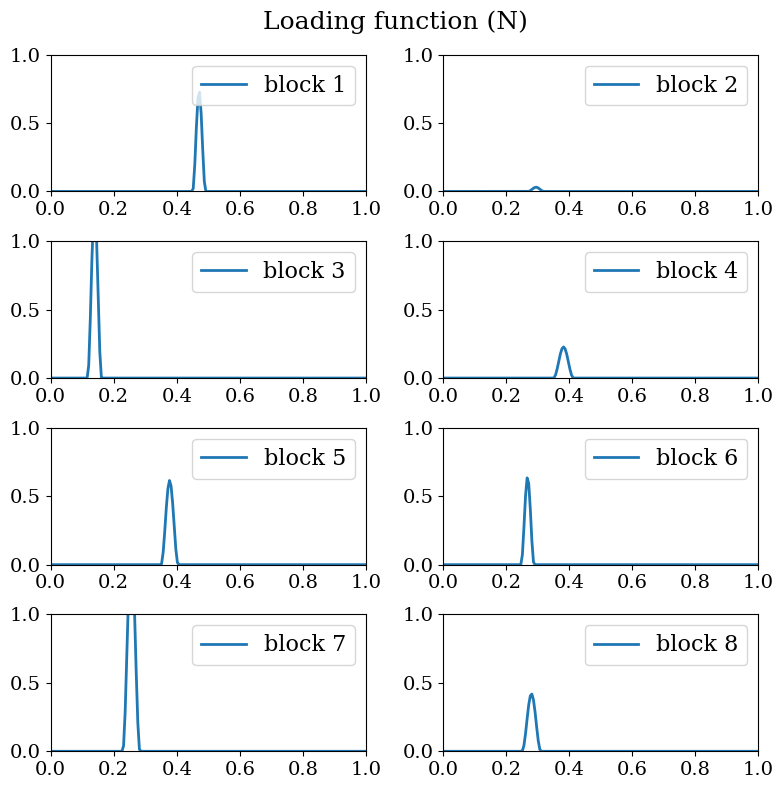

In [24]:
def random_input(key, ts):
    split_key = random.split(key, 3)
    amplitude = jax.random.uniform(split_key[0], minval=-0.005, maxval=0.1, shape=(n_excited_blocks,)) * spacing
    # print(amplitude)
    amplitude = - jax.nn.relu(amplitude)
    loading_rate = jax.random.uniform(split_key[1], minval=15., maxval=25., shape=(n_excited_blocks,))
    # input_delay = jax.random.uniform(split_key[2], minval=1.5, maxval=20.0, shape=(n_excited_blocks,))**(-1)
    input_delay = jax.random.randint(split_key[2], minval=1, maxval=7, shape=(n_excited_blocks,)) * 0.1 + jnp.clip(jax.random.normal(split_key[2], shape=(n_excited_blocks,)),min=-1,max=1)*0.05
    input_delay = jnp.clip(input_delay, min=0.0, max=1.0)
    # input_delay = jax.random.choice(split_key[2], 0.1*jnp.arange(1,9), shape=(n_excited_blocks,), replace=False)+ jnp.clip(jax.random.normal(split_key[2], shape=(n_excited_blocks,))-1,min=-2,max=0)*0.03
    output_data = func_1(None, ts, amplitude, loading_rate, input_delay)
    return output_data

def loading_fn(state, t, amplitude, loading_rate, input_delay):
    time_array = t-input_delay
    loading_vector = vmap(pulse, in_axes=(0,0,0))(time_array, amplitude, loading_rate)
    return loading_vector

angle_cut = 360. / geometry.n_piece
def map_func(output_data_single):
    output_data_temp = jnp.zeros( (n_timepoints, 2*n_excited_blocks) ) # (ts, boundary blocks * 2)
    for i in range(n_excited_blocks):
        normal_angle = (+180 - angle_cut/2. - angle_cut * i) * jnp.pi / 180.
        output_data_temp = output_data_temp.at[:,i].set( output_data_single[:,i] * jnp.cos(normal_angle) )
        output_data_temp = output_data_temp.at[:,n_excited_blocks+i].set( output_data_single[:,i] * jnp.sin(normal_angle) )
    return output_data_temp


func_1 = vmap(loading_fn, in_axes=(None,0,None,None,None))
# func_2 = vmap(func_1, in_axes=(None,None,0,0,0))
ts = jnp.linspace(0, simulation_time, n_timepoints)
# output_data = func_1(None, ts, amplitude, loading_rate, input_delay)
key = random.PRNGKey(0)
keys = random.split(key, 300)
output_data = vmap(random_input, in_axes=(0,None))(keys, ts)

for count in range(2):
    output_data_temp = output_data[count]
    plt.figure(figsize=(8,8))
    for i in range(n_excited_blocks):
        plt.subplot(n_excited_blocks//2,2,i+1)
        plt.plot(ts, -output_data_temp[:,i], label=f"block {i+1}")
        plt.ylim(0.0, 1.0)
        # plt.ylabel("Loading (N)")
        plt.legend()
    plt.suptitle("Loading function (N)")
    plt.tight_layout()
    plt.show()

output_data_all = vmap(map_func)(output_data)

# inputs = (horizontal_shifts, vertical_shifts)
# solution_all = vmap(forward_problem, in_axes=(None,0,None,None,None))(inputs, output_data_all, free_DOF_ids, constrained_DOF_ids, all_DOF_ids)

In [10]:
solution_all.shape

(300, 200, 3, 309, 3)

In [11]:
data_dict = {"output_data": output_data, "input_data": solution_all}
with open(f"040226_circular_structure_dataset_n_source_8_size_{n1_blocks}.pickle", "wb") as f:
    pickle.dump(data_dict,f)

In [27]:
# measure_idx = jnp.array([22, 38, 69, 78, 113, 122, 140, 158])
measure_idx = jnp.array([135, 150, 225, 270, 315, 365, 400, 470])

input_data = jnp.zeros_like(data_dict["input_data"][:,:,2,measure_idx,:].squeeze()) # (N, time_steps, 3)
input_data = input_data.at[:,:,:,0:2].set(data_dict["input_data"][:,:,2,measure_idx,0:2].squeeze()) # (N, time_steps, 2)
input_data = input_data.at[:,:,:,2].set(data_dict["input_data"][:,:,1,measure_idx,2].squeeze()) # (N, time_steps, 2)
N = input_data.shape[0]
input_data = input_data.reshape((N, n_timepoints, -1))

measure_idx_tag = "135_150_225_270_315_365_400_470"
data_dict = {"output_data": output_data, "input_data": input_data}
with open(f"040226_circular_structure_dataset_n_source_16_exp_param_size_{n1_blocks}_{n2_blocks}_idx_{measure_idx_tag}.pickle", "wb") as f:
    pickle.dump(data_dict,f)

In [18]:
measure_idx = jnp.array([100, 110, 358, 368])
# measure_idx = jnp.array([122, 134, 393, 405])

input_data = jnp.zeros_like(data_dict["input_data"][:,:,2,measure_idx,:].squeeze()) # (N, time_steps, 3)
input_data = input_data.at[:,:,:,0:2].set(data_dict["input_data"][:,:,2,measure_idx,0:2].squeeze()) # (N, time_steps, 2)
input_data = input_data.at[:,:,:,2].set(data_dict["input_data"][:,:,1,measure_idx,2].squeeze()) # (N, time_steps, 2)
N = input_data.shape[0]
input_data = input_data.reshape((N, n_timepoints, -1))

measure_idx_tag = "_".join([str(idx) for idx in measure_idx])
data_dict = {"output_data": output_data, "input_data": input_data}
with open(f"012326_circular_structure_dataset_n_source_8_exp_param_size_{n1_blocks}.pickle", "wb") as f:
    pickle.dump(data_dict,f)

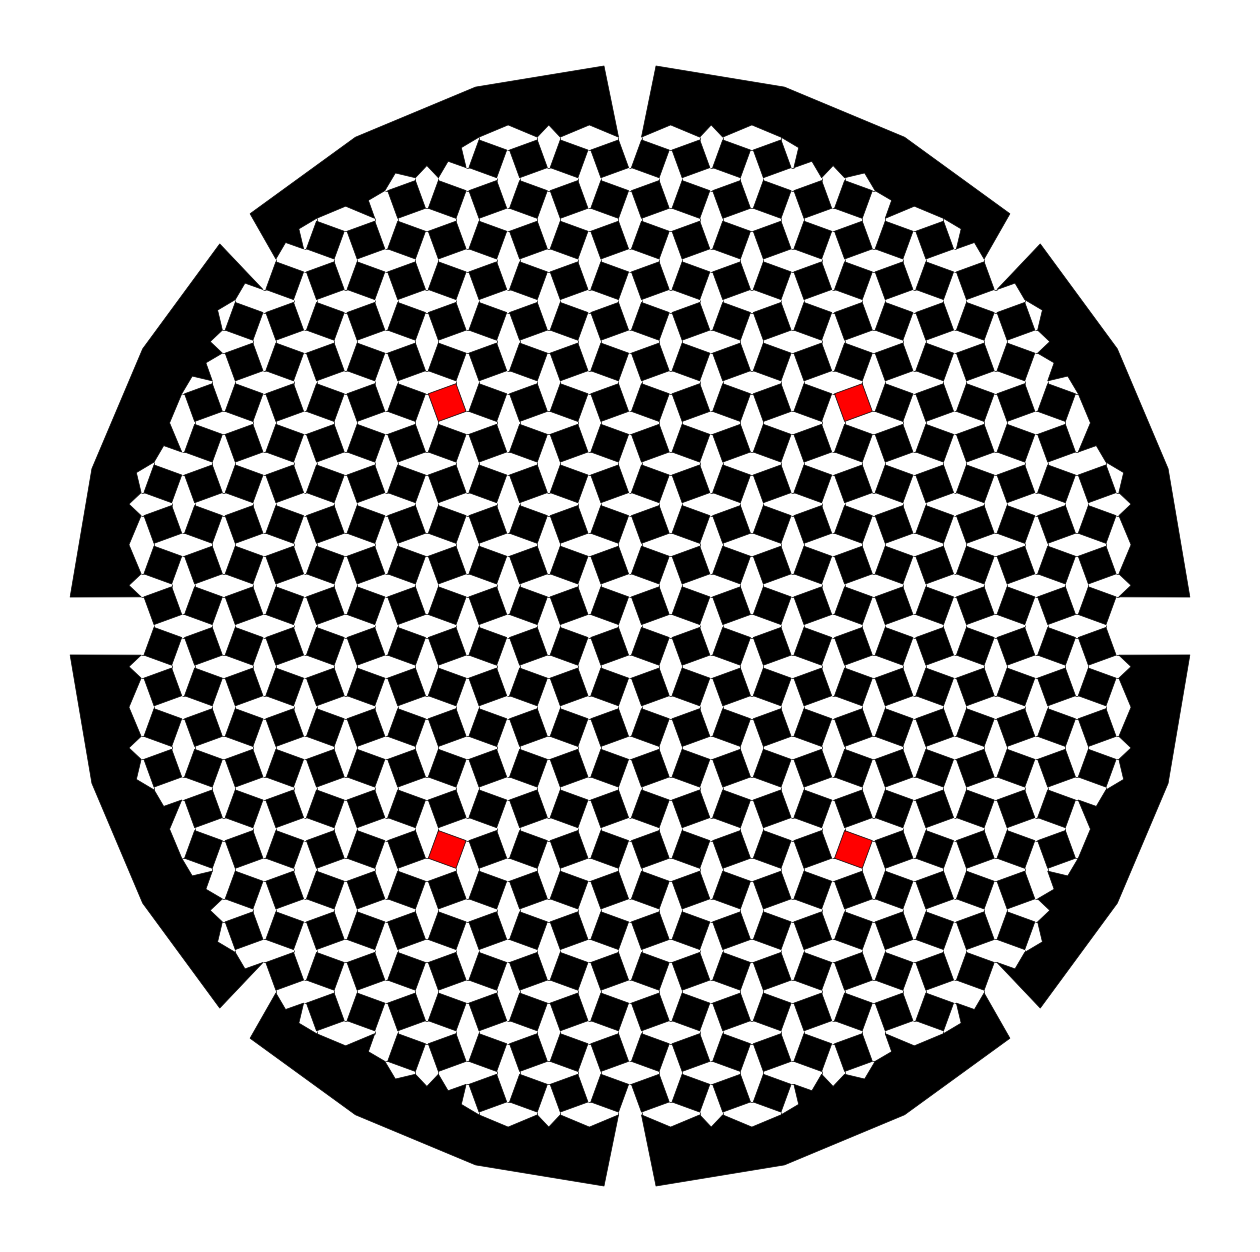

In [22]:
from blockymetamaterials.plotting_input import plot_geometry, compute_xy_limits
center_idx = geometry.n_quads//2

# generate animation
design_values = (horizontal_shifts, vertical_shifts)
block_centroids_temp = block_centroids(horizontal_shifts, vertical_shifts)
centroid_node_vectors_temp = centroid_node_vectors(horizontal_shifts, vertical_shifts)

shell_verts = jnp.concatenate([ centroids + vertices for centroids, vertices in zip(block_centroids_temp, centroid_node_vectors_temp)], axis=0)
xlim, ylim = compute_xy_limits(
    shell_verts) + 0.5*geometry.spacing * jnp.array([-1, 1])
color_list = ['k' for _ in range(geometry.n_blocks)]

# measure_idx = [ 14, 18, 78, 82 ] # for 15x15
# measure_idx = [ 5, 8, 17, 20 ] # for 10x10
# measure_idx = [33, 40, 117, 124] # for 20x20
# measure_idx = [66, 74, 247, 255] # for 27x27
# measure_idx = [67, 75, 217, 225] # for 25x25
# measure_idx= [79, 88, 298, 307] # for 30x30
measure_idx = [100, 110, 358, 368] # for 32x32
# measure_idx = [122, 134, 393, 405] # for 33x33
#  measure_idx = [150, 162, 414, 426] for 35x35

for i in measure_idx:
    color_list[i] = 'r'

fig, ax = plt.subplots(figsize=(16,16))
block_idx = jnp.concatenate( (geometry.blocks_inside, jnp.arange(geometry.n_quads, geometry.n_quads+geometry.n_piece)), dtype=int  )
colors = 'k'
plot_geometry(block_centroids_temp,
              centroid_node_vectors_temp,
              _bond_connectivity,
              color=color_list, ax=ax)
ax.axis("equal")
ax.axis("off")
plt.show()

## Results

In [ ]:
coopt_filename= "/home/kna35/GaTech Dropbox/Kyungmi Na/physical-intelligence-change/notebooks/checkpoint_circular_structure_cooptimization_n_source_16_size_32_measure_idx_100_110_358_368.pickle"
with open(coopt_filename, "rb") as f:
    record_dict = pickle.load(f)

loss_record = jnp.array(record_dict["loss_record"])
param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]

meta_params_init = jnp.concatenate((horizontal_shifts.flatten(), vertical_shifts.flatten()))
param_record.insert(0, meta_params_init)


coopt_filename= "/home/kna35/GaTech Dropbox/Kyungmi Na/physical-intelligence-change/notebooks/041626_circular_structure_cooptimization_n_source_16_size_32_measure_idx_100_110_358_368.pickle"

record_dict["design_record"] = param_record

# with open(coopt_filename, "wb") as f:
#     pickle.dump(record_dict, f)

In [25]:
with open(coopt_filename, "rb") as f:
    record_dict = pickle.load(f)

loss_record = jnp.array(record_dict["loss_record"])
param_record = record_dict["design_record"]

design_idx = int(jnp.argmin(loss_record))
meta_params = param_record[design_idx]

hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
horizontal_shifts_opt = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
vertical_shifts_opt = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))
inputs = (horizontal_shifts_opt, vertical_shifts_opt)
solution_all = vmap(forward_problem, in_axes=(None,0,None,None,None))(inputs, output_data_all, free_DOF_ids, constrained_DOF_ids, all_DOF_ids)

measure_idx = jnp.array([100, 110, 358, 368])

input_data = jnp.zeros_like(solution_all[:,:,2,measure_idx,:].squeeze()) # (N, time_steps, 3)
input_data = input_data.at[:,:,:,0:2].set(solution_all[:,:,2,measure_idx,0:2].squeeze()) # (N, time_steps, 2)
input_data = input_data.at[:,:,:,2].set(solution_all[:,:,1,measure_idx,2].squeeze()) # (N, time_steps, 2)
N = input_data.shape[0]
input_data = input_data.reshape((N, n_timepoints, -1))

key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])
mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]


duration :  3.2545089721679688


2026-04-16 10:49:41.463697: E external/xla/xla/service/slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_forward_problem] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2026-04-16 10:49:44.874084: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 2m3.410462982s

********************************
[Compiling module jit_forward_problem] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


In [28]:

record_dict["optimized_design"] = (training_input_data, training_output_data, test_input_data, test_output_data)
record_dict["opt_idx"] = design_idx

with open(coopt_filename, "wb") as f:
    pickle.dump(record_dict, f)

In [ ]:
filename = f"012326_circular_structure_dataset_n_source_8_exp_param_size_{n1_blocks}_optimized.pickle"

with open(filename, "rb") as f:
    data_dict = pickle.load(f)

input_data = data_dict["input_data"]
output_data = data_dict["output_data"]


key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])
mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

for i in range(4):
    for j in range(4):
        plt.figure(figsize=(8,8))
        for k in range(3):
            plt.subplot(3,1,k+1)
            plt.plot(ts, test_input_data[i,:,k+3*j], label=f"True output block {j+1}")
        plt.show()

In [38]:
filename = "012326_circular_structure_dataset_n_source_8_exp_param_size_32.pickle"
with open(filename, "rb") as f:
    data_dict = pickle.load(f)

input_data = data_dict["input_data"]
output_data = data_dict["output_data"]

filename = "040226_circular_structure_dataset_n_source_8_size_32.pickle"
with open(filename, "rb") as f:
    data_dict = pickle.load(f)

    
print(data_dict["input_data"].shape, data_dict["output_data"].shape)
print("input_data.ndim > 3")
input_data_compare = jnp.zeros_like(data_dict["input_data"][:,:,2,measure_idx,:].squeeze()) # (N, time_steps, 3)
input_data_compare = input_data_compare.at[:,:,:,0:2].set(data_dict["input_data"][:,:,2,measure_idx,0:2].squeeze()) # (N, time_steps, 2)
input_data_compare = input_data_compare.at[:,:,:,2].set(data_dict["input_data"][:,:,1,measure_idx,2].squeeze()) # (N, time_steps, 2)
N = input_data.shape[0]
input_data_compare = input_data.reshape((N, n_timepoints, -1))
output_data_compare = data_dict["output_data"]

(300, 200, 3, 476, 3) (300, 200, 8)
input_data.ndim > 3


In [29]:
print( jnp.sum(jnp.abs(input_data_compare - input_data)) )
print( jnp.sum(jnp.abs(output_data_compare - output_data)) )

0.0
0.0


In [ ]:
# prediction data
params_init = in_param_record[0][0]

key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])
mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

mm_scaler = minmax_scaler(training_input_data, training_output_data)
mm_scaler.information()

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

model = TimeSeriesCNN(output_features=n_piece)
init_params = model.init(key, input_data)
preds = model.apply(init_params, input_data)

pred_y = model.apply(params_init, train_data_normalized)
pred_y_test = model.apply(params_init, test_data_normalized)

mse_init = jnp.mean((pred_y - train_output_normalized)**2)
print(f"Initial training loss : {mse_init:.4e}")
mse_test_init = jnp.mean((pred_y_test - test_output_normalized)**2)
print(f"Initial test loss : {mse_test_init:.4e}")

(1, 1, 12) (1, 1, 12)
(1, 1, 8) (1, 1, 8)
data min :  [[[-2.22506740e+03 -1.75713915e+03 -3.72932052e-01 -2.23519877e+03
   -2.31808639e+03 -5.44826110e-01 -1.76072610e+03 -1.49390336e+03
   -6.14434188e-01 -1.75170680e+03 -1.57873850e+03 -6.75954237e-01]]]
data max :  [[[1.70888022e+03 1.75008020e+03 6.25884055e-01 2.30460184e+03
   1.99136248e+03 7.92606997e-01 1.68728683e+03 1.70501780e+03
   4.31035265e-01 2.09793254e+03 1.79876991e+03 5.53070918e-01]]]
test data min :  [[[-1.60358077 -1.58009485 -1.60788117 -1.60656839 -1.60676801
   -1.59578997 -1.60946323 -1.58958608]]]
test data max :  [[[-0. -0. -0. -0. -0. -0. -0. -0.]]]
Initial training loss : 6.3738e-04
Initial test loss : 6.7271e-04


In [32]:
_, pred_y_org = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)

In [39]:

key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])
mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

In [ ]:
for i in range(4):
    for j in range(4):
        plt.figure(figsize=(8,8))
        for k in range(3):
            plt.subplot(3,1,k+1)
            plt.plot(ts, test_input_data[i,:,k+3*j], label=f"True output block {j+1}")
        plt.show()


In [35]:
training_input_data.shape

(271, 200, 12)

In [48]:
jnp.mean(jnp.array(opt_prediction_error))

Array(5.03574631, dtype=float64)

In [46]:
data_dict["prediction_error"] = opt_prediction_error
data_dict["nn_param"] = params_opt
# opt_prediction_error

In [47]:
filename = f"012326_circular_structure_dataset_n_source_8_exp_param_size_{n1_blocks}_optimized_include_prediction.pickle"

with open(filename, "wb") as f:
    pickle.dump(data_dict, f)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Optimized training loss : 3.2568e-04
Optimized test loss : 2.8995e-04
Optimized training loss in original scale : 8.3490e-04
Optimized test loss in original scale : 7.4338e-04
TEST


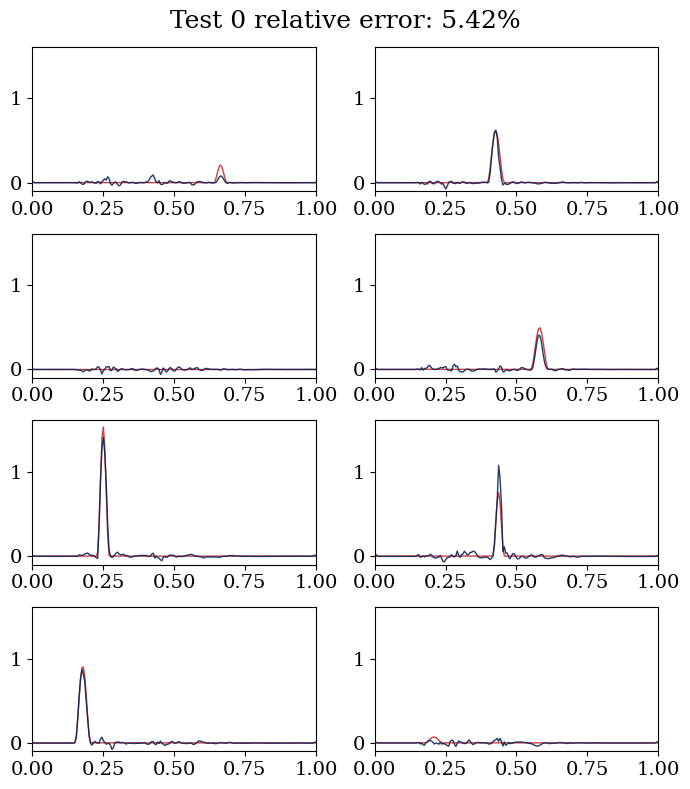

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


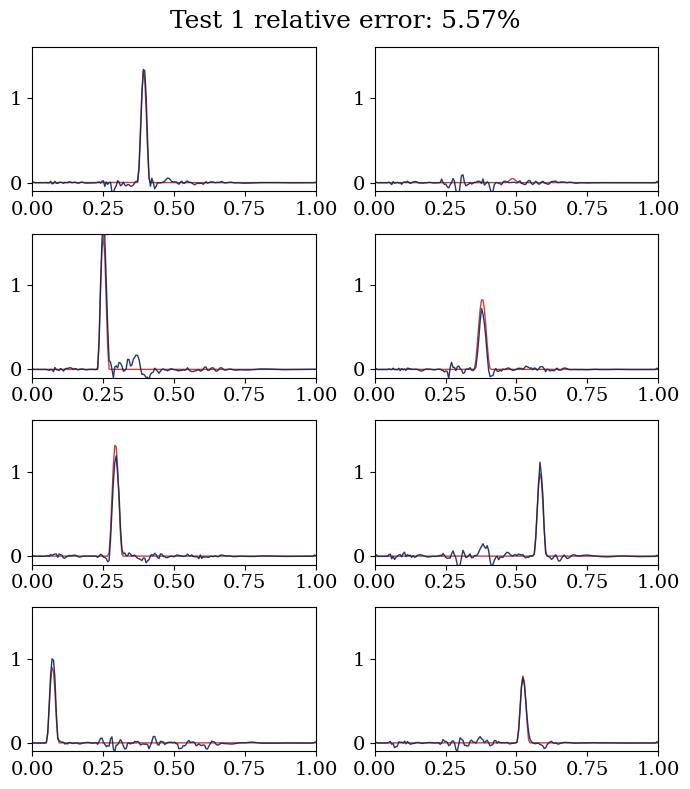

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


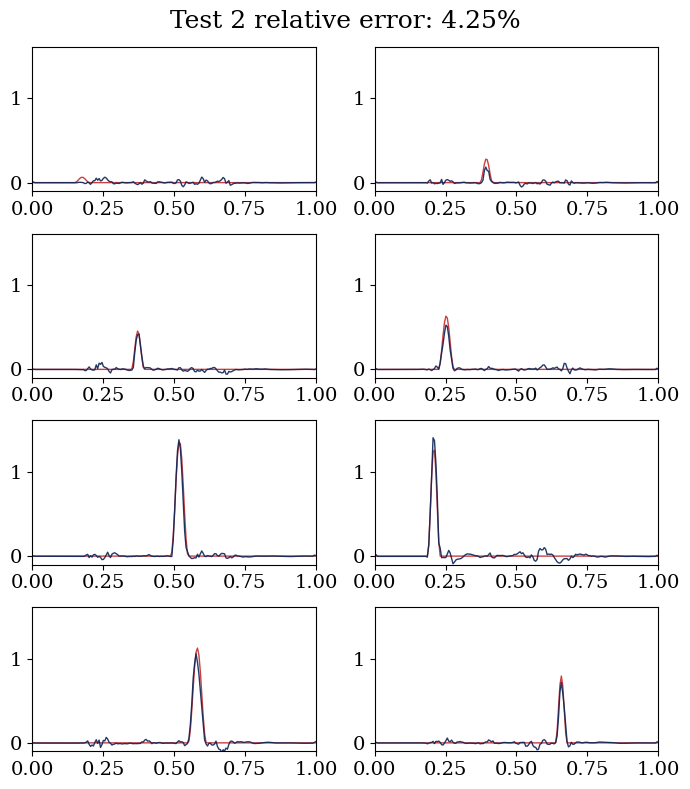

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


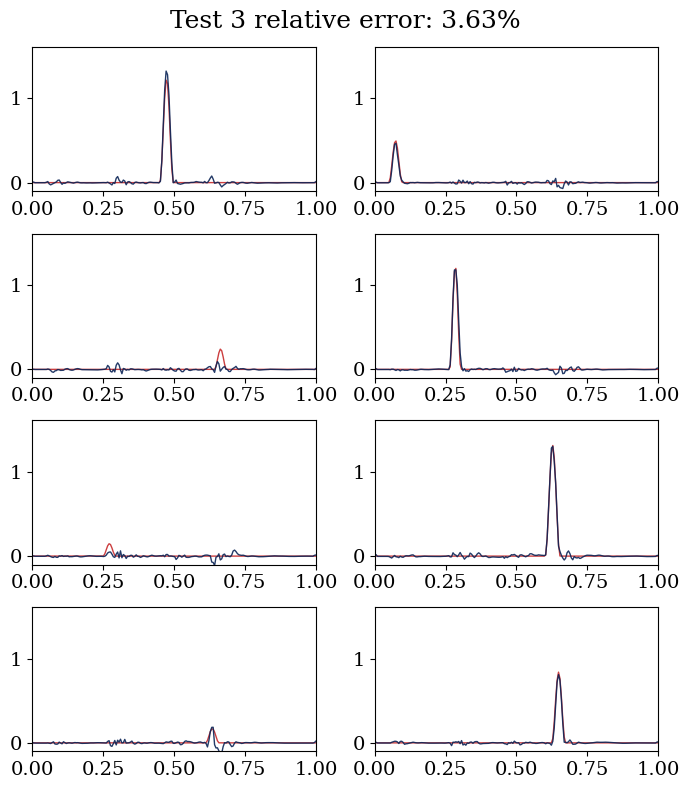

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


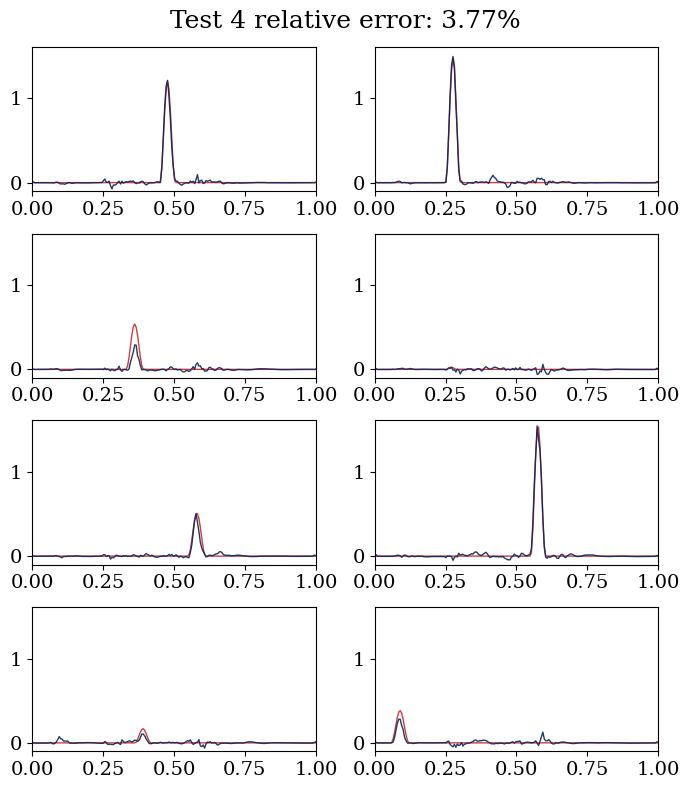

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


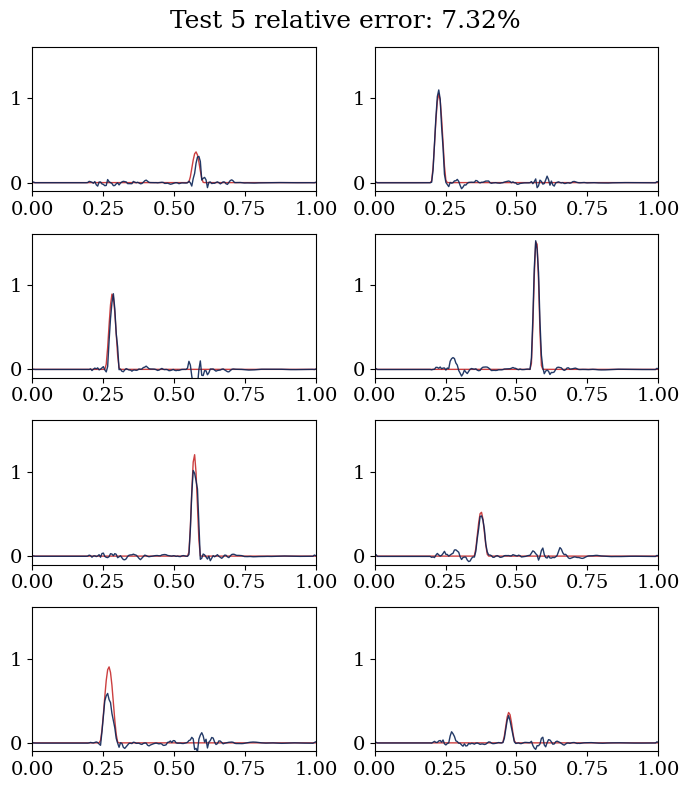

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


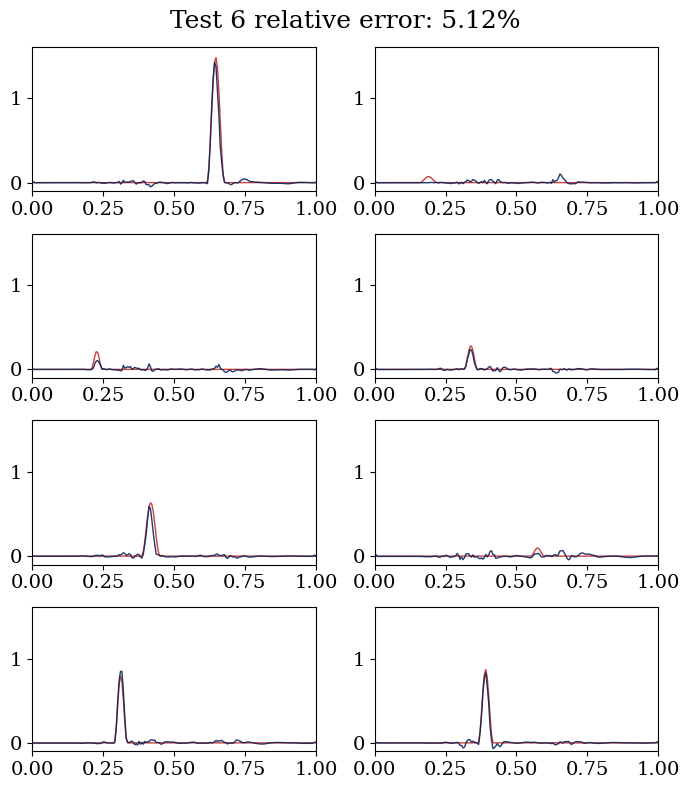

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


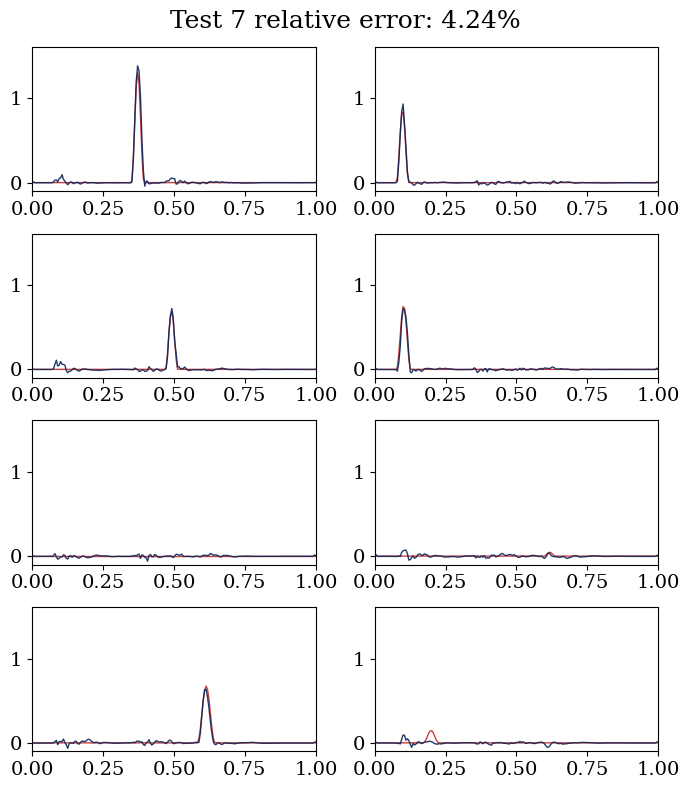

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


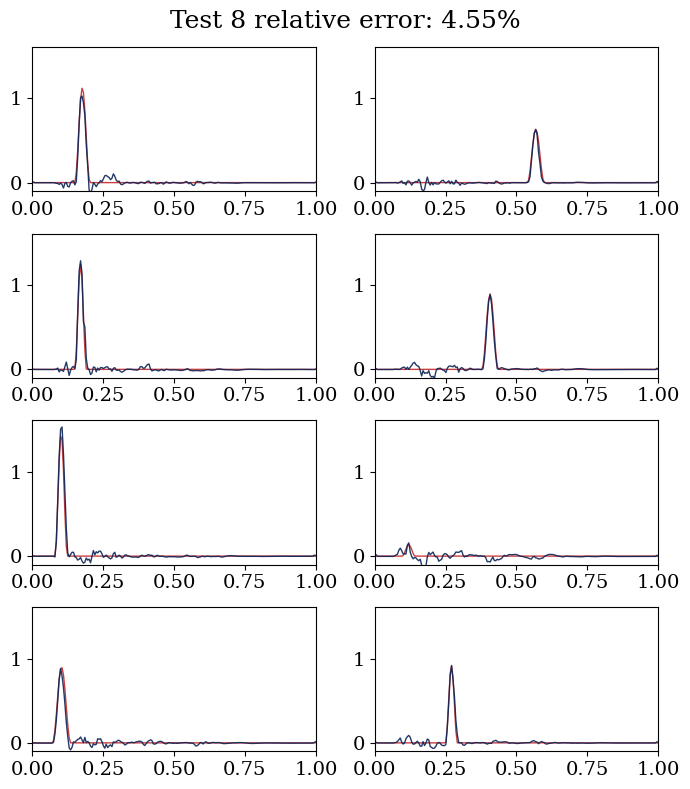

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


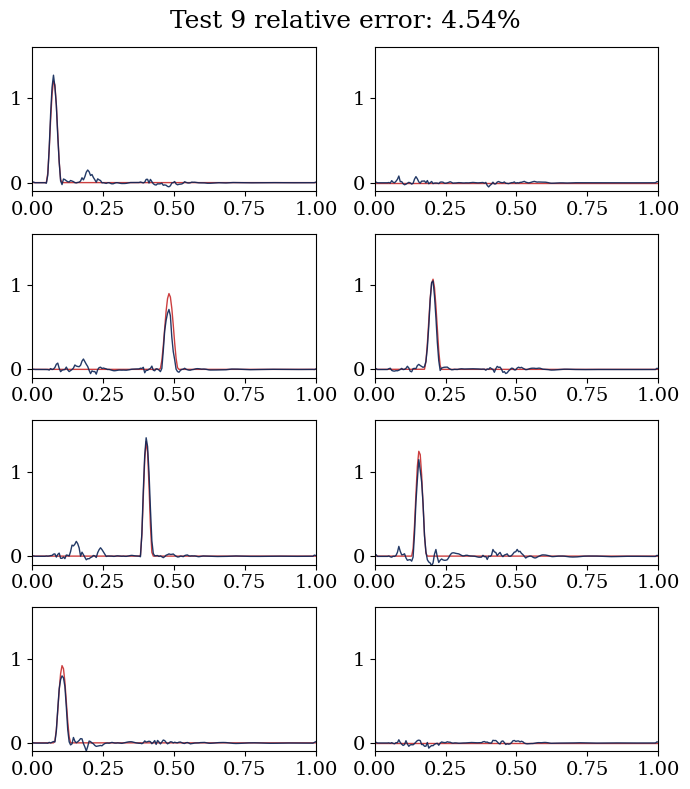

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


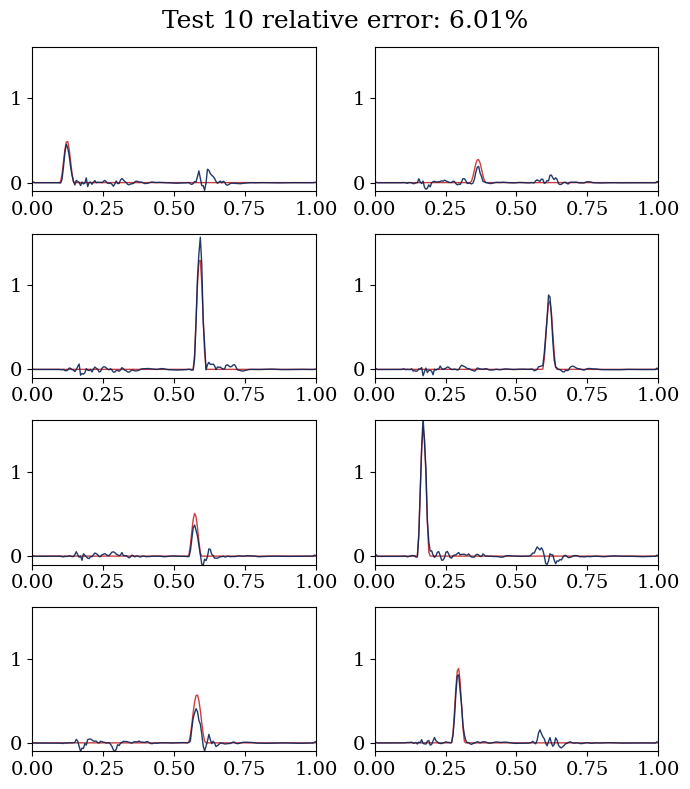

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


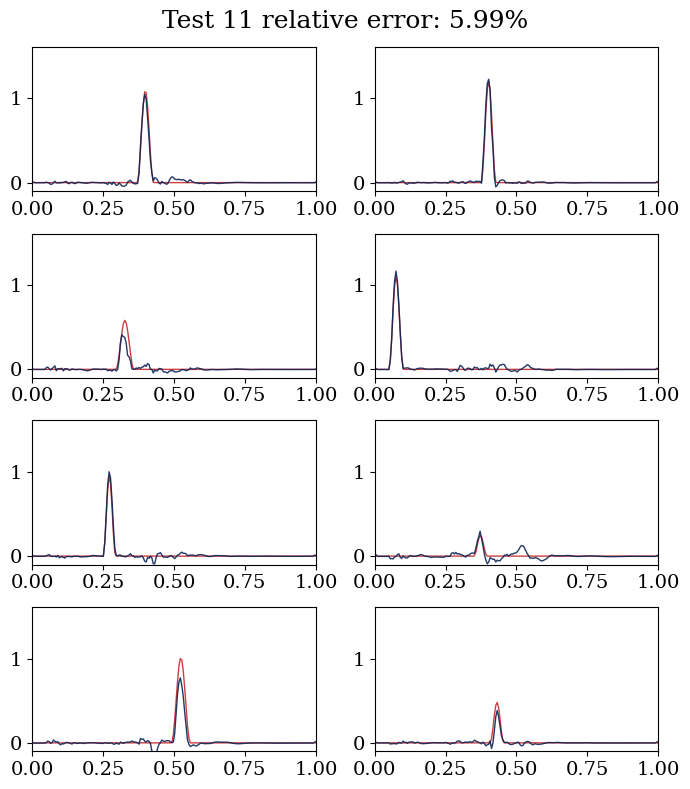

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


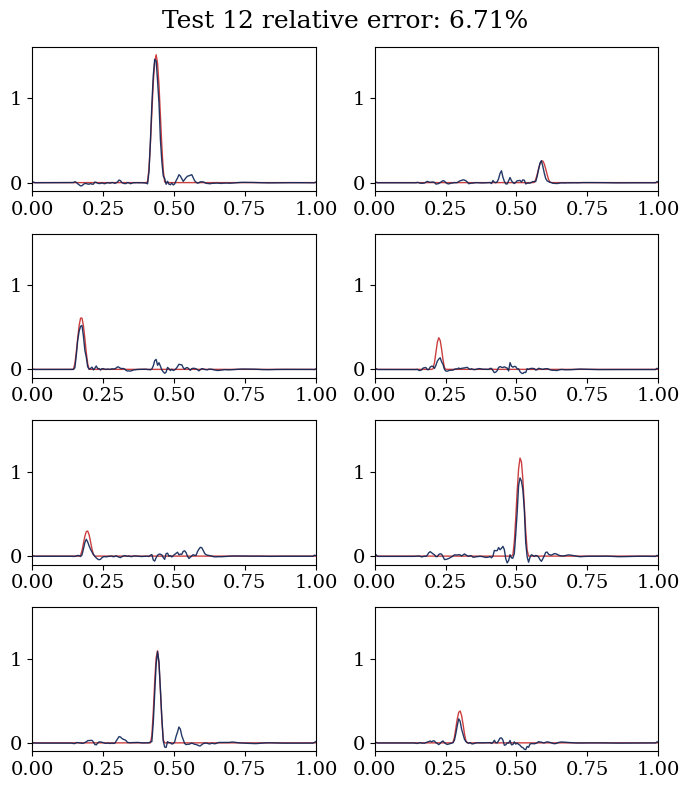

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


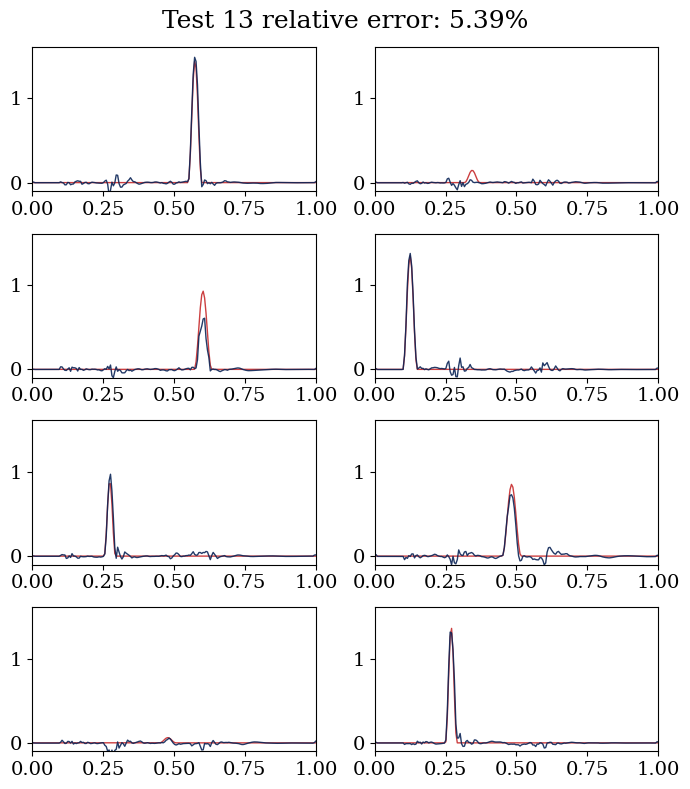

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


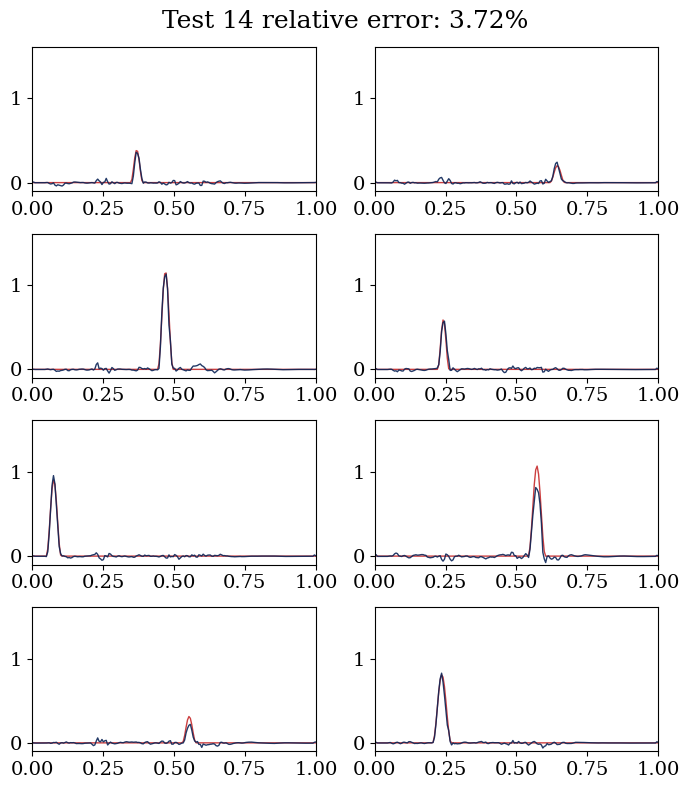

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


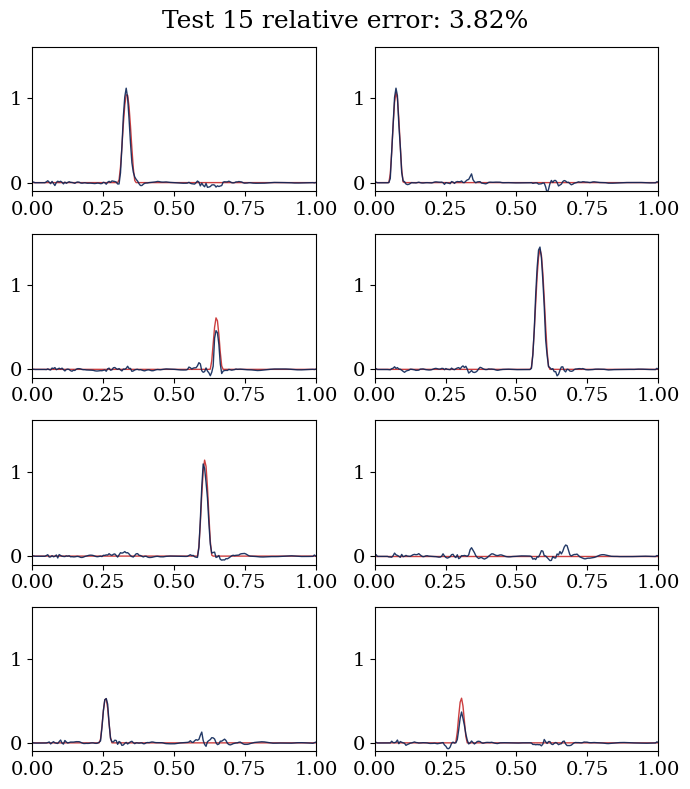

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


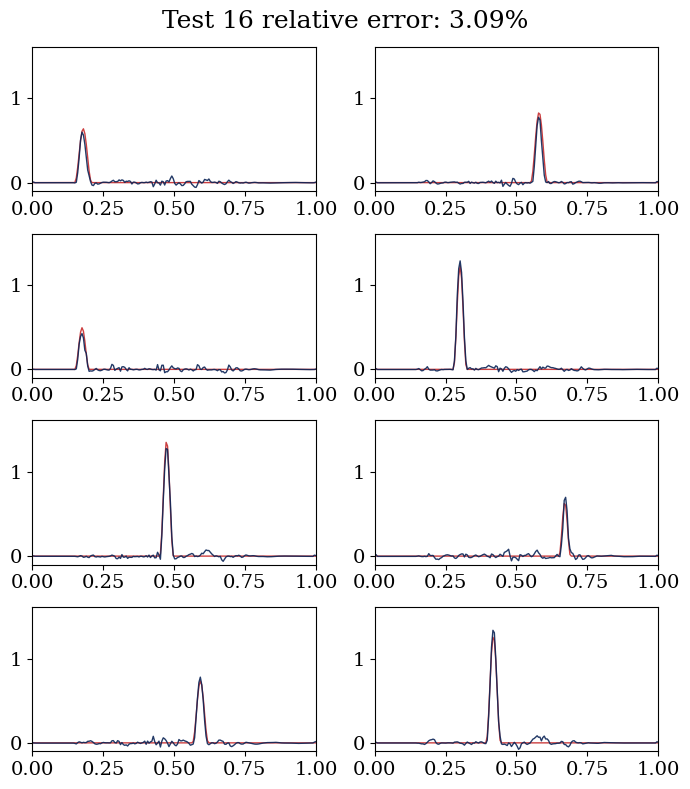

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


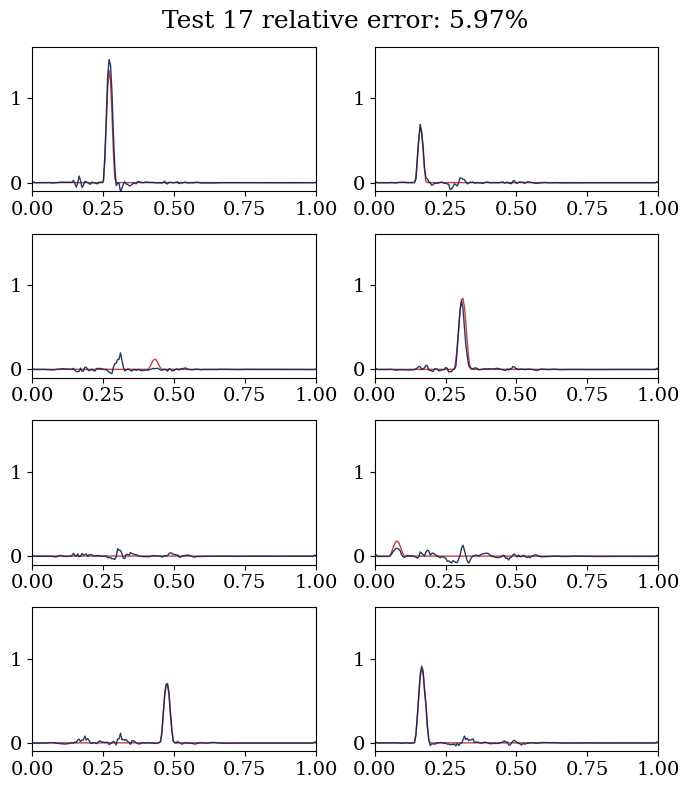

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


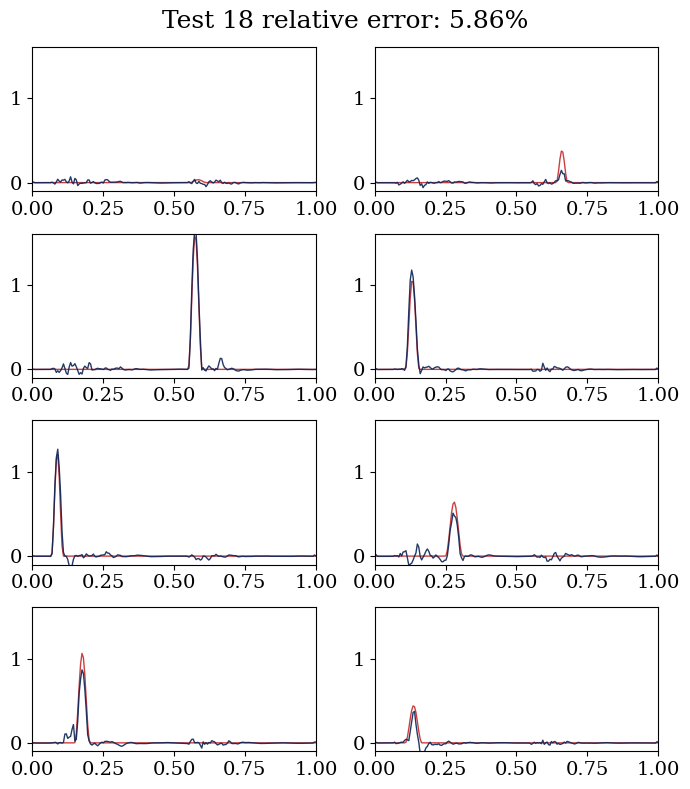

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


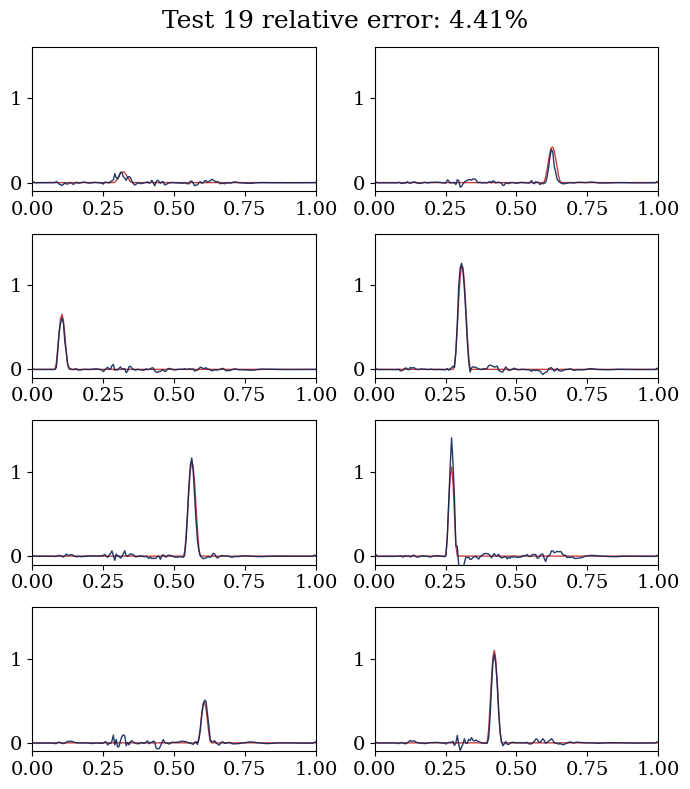

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


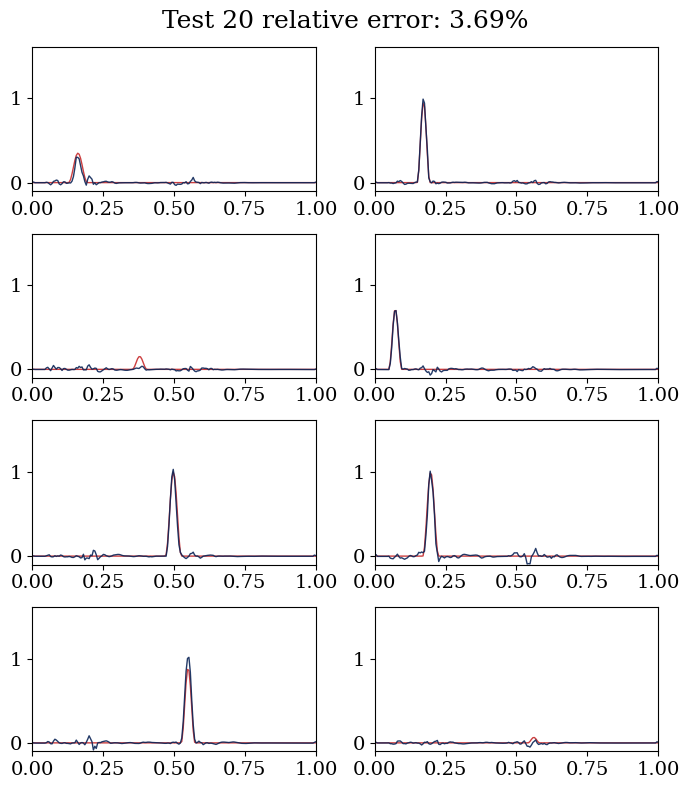

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


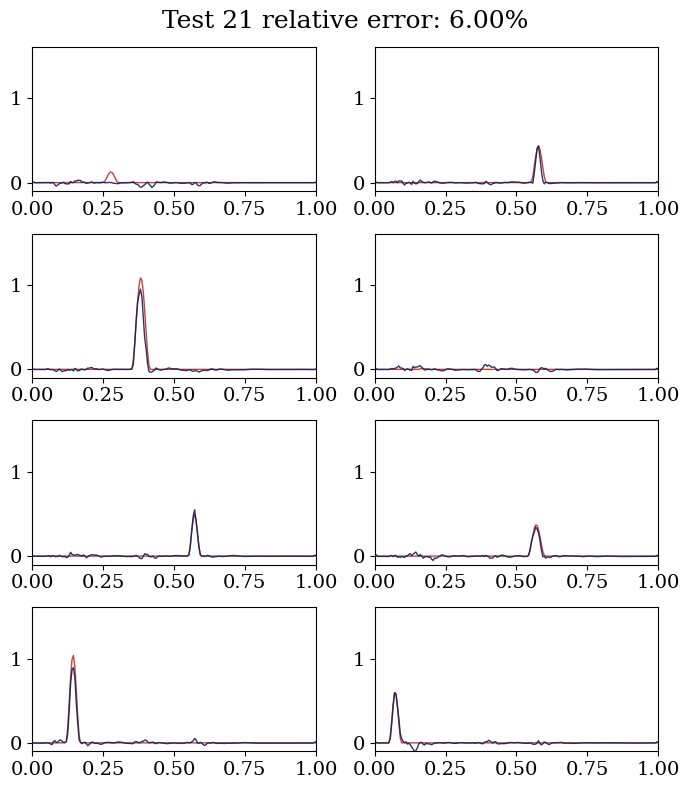

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


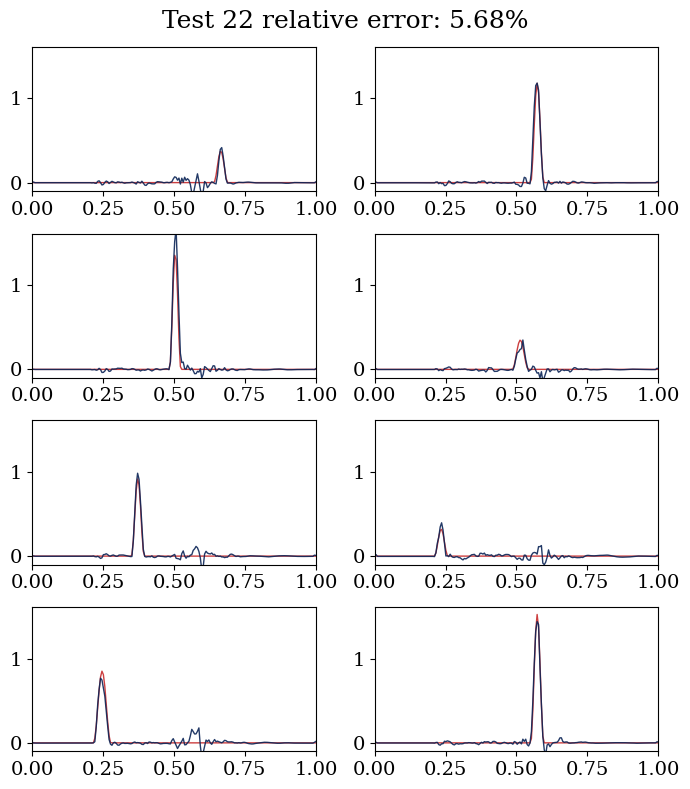

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


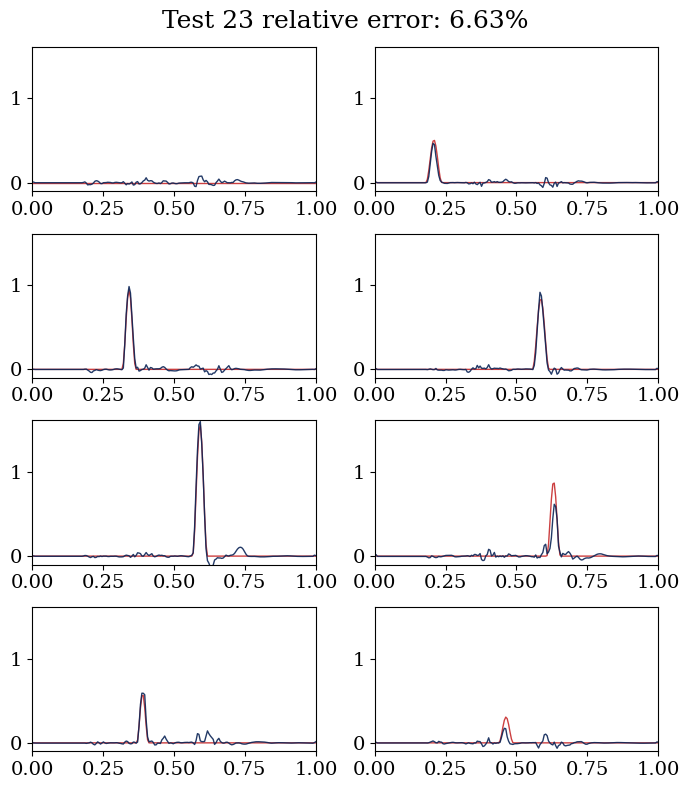

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


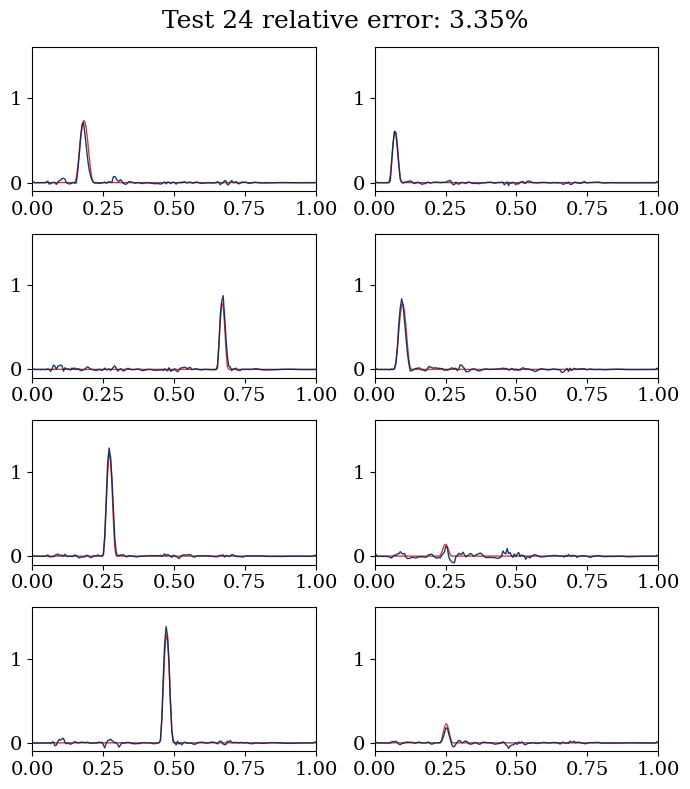

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


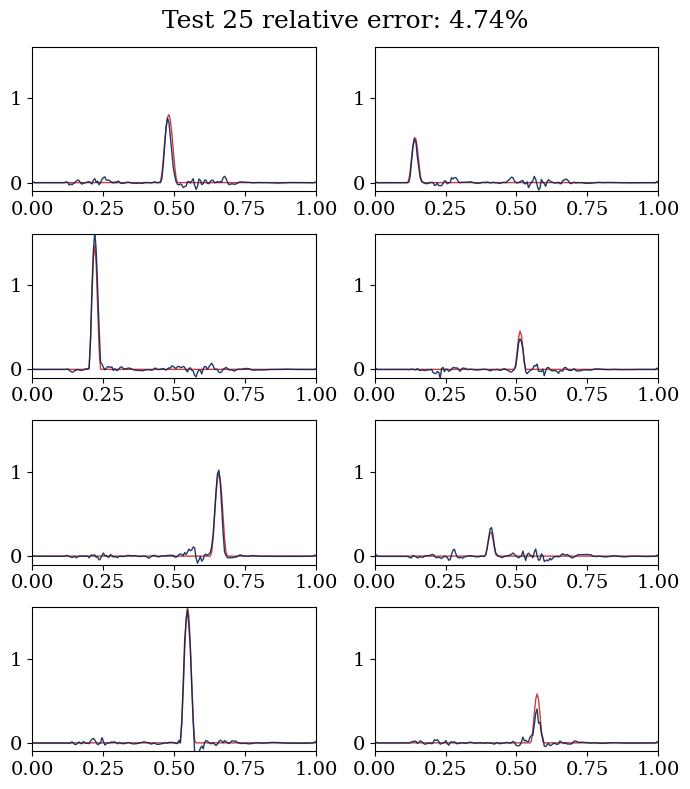

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


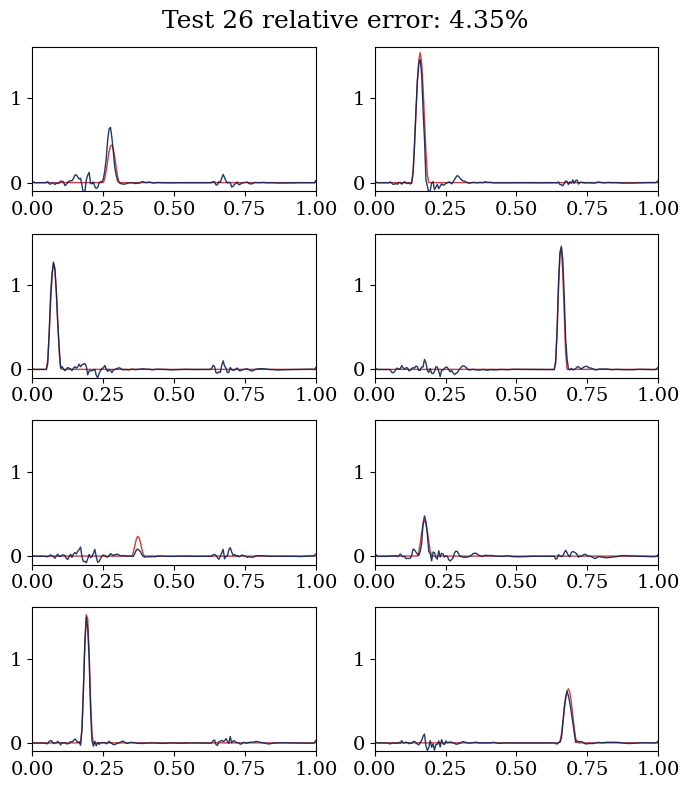

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


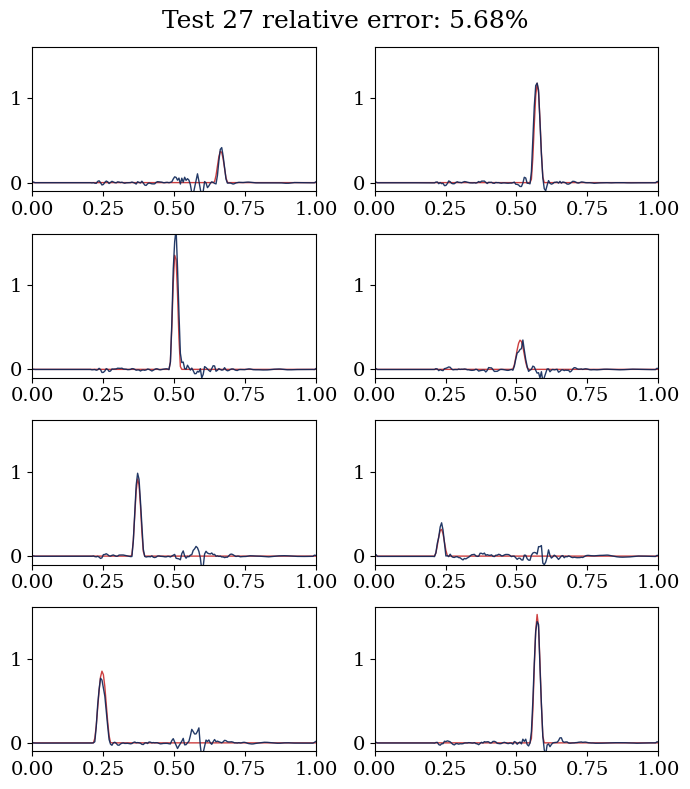

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


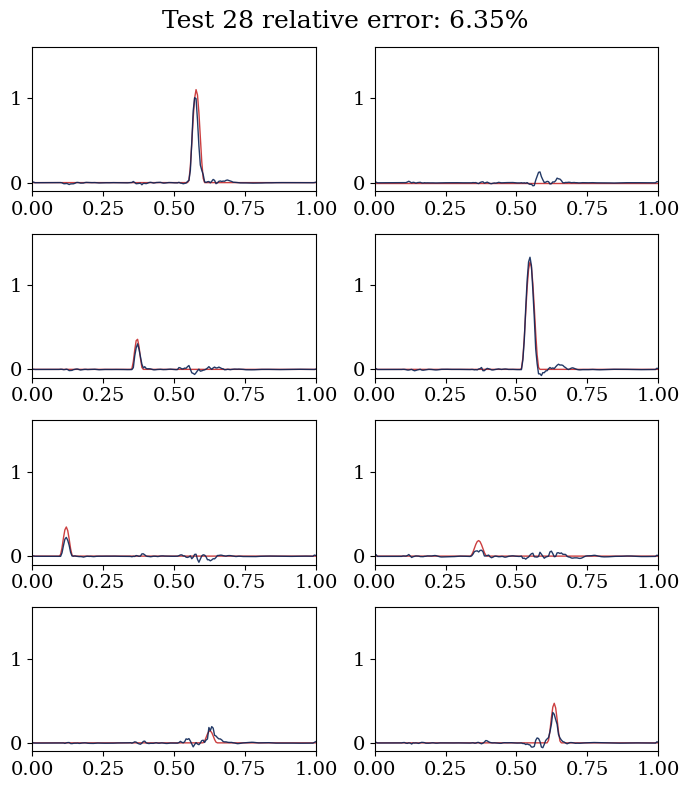

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


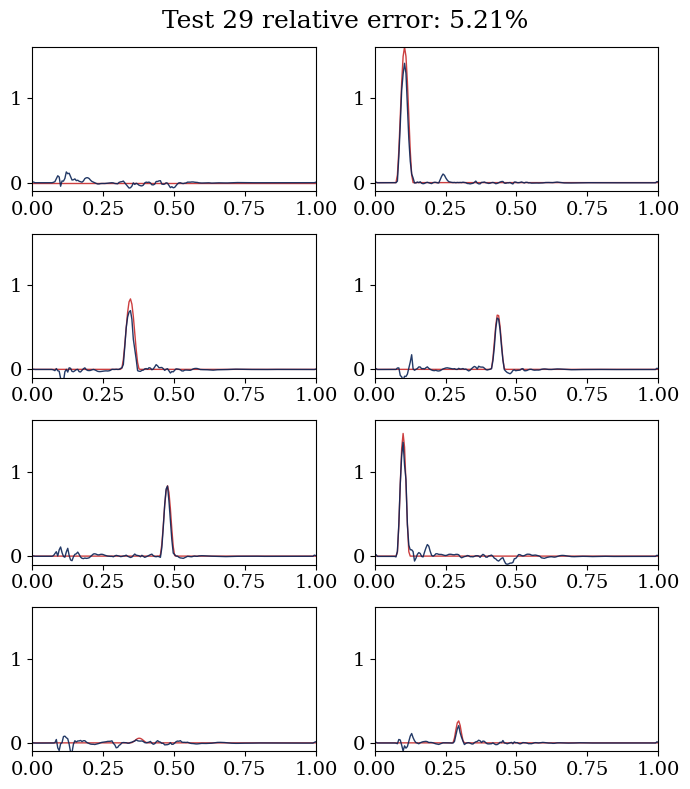

In [45]:
params_opt = in_param_record[design_idx][0]

# with open(coopt_filename, "rb") as f:
#     record_dict = pickle.load(f)  
# training_input_data, training_output_data, test_input_data, test_output_data = record_dict["optimized_design"]


train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

pred_y = model.apply(params_opt, train_data_normalized)
pred_y_test = model.apply(params_opt, test_data_normalized)

_, pred_y_org_opt = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test_opt = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)

mse = jnp.mean((pred_y - train_output_normalized)**2)
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)

print(f"Optimized training loss : {mse:.4e}")
print(f"Optimized test loss : {mse_test:.4e}")

mse_opt = jnp.mean((pred_y_org_opt - training_output_data)**2)
mse_test_opt = jnp.mean((pred_y_org_test_opt - test_output_data)**2)
print(f"Optimized training loss in original scale : {mse_opt:.4e}")
print(f"Optimized test loss in original scale : {mse_test_opt:.4e}")

improvement = mse_test_opt / mse_test_init
        
min_value = jnp.min(jnp.concatenate([training_output_data, test_output_data]))
color_list = ["#cc3f40", "#bdccd4", "#0b2456",]
# color_list = ["k", "b", "r",]

init = False
save_fig = True
name="4_sensors"

N = 100
print("TEST")
init_prediction_error = []
opt_prediction_error = []
for i in range(30):
    fig, axes = plt.subplots(n_piece//2,2, figsize=(7,1.*n_piece))
    axes = axes.flatten()
    for j in range(n_piece):
        ax = axes[j]
        ax.plot( ts, -test_output_data[i,:,j], color=color_list[0], linewidth=1.0, label="True")
        ax.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[2], alpha=0.9, linewidth=1.0, label="Prediction from CNN (optimized)")
        if init:
            ax.plot( ts, -pred_y_org_test[i,:,j], color=color_list[1], alpha=0.9, linewidth=1.0, label="Prediction from CNN (initial)")
        ax.set_ylim(-0.1, -min_value)
    # init_loss = jnp.mean((pred_y_org_test[i] - test_output_data[i])**2)
    # opt_loss = jnp.mean((pred_y_org_test_opt[i] - test_output_data[i])**2)
    relative_error = jnp.sum((test_output_data[i,:,:]-pred_y_org_test_opt[i,:,:])**2)/jnp.sum(test_output_data[i,:,:]**2)*100.0
    init_relative_error = jnp.sum((test_output_data[i,:,:]-pred_y_org_test[i,:,:])**2)/jnp.sum(test_output_data[i,:,:]**2)*100.0
    # plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.5))
    # plt.legend()
    plt.suptitle(f"Test {i} relative error: {relative_error:.2f}%")
    if init:
        plt.suptitle(f"Test {i} relative error: {relative_error:.2f}% (initial: {init_relative_error:.2f}%)")
    init_prediction_error.append(init_relative_error)
    opt_prediction_error.append(relative_error)
    plt.tight_layout()
    if save_fig:
        plt.savefig(f"Figure/Circular_structure/{name}/{n1_blocks}x{n2_blocks}/{name}_sim_opt_prediction_test_data_{i}.eps")
        plt.savefig(f"Figure/Circular_structure/{name}/{n1_blocks}x{n2_blocks}/{name}_sim_opt_prediction_test_data_{i}.png")
    plt.show()

In [13]:
from blockymetamaterials.plotting_input import plot_geometry, compute_xy_limits
def visualize_data(data_filename, coopt_filename, measure_idx, size, prediction=False, save_fig=False, name="4_sensors", init = False):
    
    with open(data_filename, "rb") as f:
        data_dict = pickle.load(f)
        
    input_data = data_dict["input_data"]
    if input_data.ndim > 3:
        print("input_data.ndim > 3")
        input_data = jnp.zeros_like(data_dict["input_data"][:,:,2,measure_idx,:].squeeze()) # (N, time_steps, 3)
        input_data = input_data.at[:,:,:,0:2].set(data_dict["input_data"][:,:,2,measure_idx,0:2].squeeze()) # (N, time_steps, 2)
        input_data = input_data.at[:,:,:,2].set(data_dict["input_data"][:,:,1,measure_idx,2].squeeze()) # (N, time_steps, 2)
        N = input_data.shape[0]
        input_data = input_data.reshape((N, n_timepoints, -1))
    output_data = data_dict["output_data"]

    with open(coopt_filename, "rb") as f:
        record_dict = pickle.load(f)

    loss_record = jnp.array(record_dict["loss_record"])
    param_record = record_dict["design_record"]
    in_param_record = record_dict["nn_record"]
    # loss_record[k] is after outer step k; design that produced it is param_record[k+1].
    # nn_record[k] is the inner solver aux after the same outer step k.
    best_loss_idx = int(jnp.argmin(loss_record))
    design_idx = best_loss_idx

    # ----------------------------------------------------------------------------- 
    # 1) Outer loss vs iteration
    # ----------------------------------------------------------------------------- 
    fig, ax = plt.subplots()
    ax.plot(jnp.arange(len(loss_record)), loss_record, color="#2c3e50", lw=1.5)
    ax.scatter(best_loss_idx, float(loss_record[best_loss_idx]), c="#c0392b", s=45, zorder=3, label=f"min (step {best_loss_idx})")
    ax.set_xlabel("Outer iteration")
    ax.set_ylabel("Outer loss")
    ax.set_title("Cooptimization outer loss")
    ax.legend()
    # ax.grid(True, alpha=0.35)
    ax.set_yscale("log")
    plt.tight_layout()
    plt.show()

    print( f"initial loss: {loss_record[0]:.4e}" )
    print( f"best loss: {loss_record[best_loss_idx]:.4e}" )

    # geometry
    meta_params = param_record[design_idx]
    hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
    horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
    vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))
    
    design_values = (horizontal_shifts, vertical_shifts)
    block_centroids_temp = block_centroids(horizontal_shifts, vertical_shifts)
    centroid_node_vectors_temp = centroid_node_vectors(horizontal_shifts, vertical_shifts)

    shell_verts = jnp.concatenate([ centroids + vertices for centroids, vertices in zip(block_centroids_temp, centroid_node_vectors_temp)], axis=0)
    xlim, ylim = compute_xy_limits(
        shell_verts) + 0.5*geometry.spacing * jnp.array([-1, 1])
    # color_list = ['k' for _ in range(geometry.n_blocks)]
    color_list = ['#0b2456' for _ in range(geometry.n_blocks)]

    for i in measure_idx:
        color_list[int(i)] = '#6bb150'
        # color_list[int(i)] = 'r'

    fig, ax = plt.subplots(figsize=(16,16))
    block_idx = jnp.concatenate( (geometry.blocks_inside, jnp.arange(geometry.n_quads, geometry.n_quads+geometry.n_piece)), dtype=int )
    plot_geometry(block_centroids_temp,
                centroid_node_vectors_temp,
                _bond_connectivity,
                color=color_list, ax=ax)
    ax.axis("equal")
    ax.axis("off")
    # plt.savefig(f"Figure/Circular_structure/structure_complexity/{name}_size_{size}_optimized_geometry.png")
    # plt.savefig(f"Figure/Circular_structure/structure_complexity/{name}_size_{size}_optimized_geometry.eps")
    # if save_fig:
    #     plt.savefig(f"Figure/Circular_structure/structure_complexity/{name}_size_{size}_optimized_geometry.png")
    #     plt.savefig(f"Figure/Circular_structure/structure_complexity/{name}_size_{size}_optimized_geometry.eps")
    plt.show()

    key = random.PRNGKey(0)
    test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
    test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])
    mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

    training_input_data = input_data[mask]
    training_output_data = output_data[mask]

    test_input_data = input_data[test_idx]
    test_output_data = output_data[test_idx]

    mm_scaler = minmax_scaler(training_input_data, training_output_data)
    mm_scaler.information()

    params_init = in_param_record[0][0]
    if size == 32:
        filename = f"012326_circular_structure_dataset_n_source_8_exp_param_size_{size}_initial.pickle"

        with open(filename, "rb") as f:
            data_dict = pickle.load(f)

        input_data = data_dict["input_data"]
        output_data = data_dict["output_data"]


        key = random.PRNGKey(0)
        test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
        test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])
        mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

        training_input_data = input_data[mask]
        training_output_data = output_data[mask]

        test_input_data = input_data[test_idx]
        test_output_data = output_data[test_idx]
    else:
        training_input_data = in_param_record[0][2]
        training_output_data = in_param_record[0][3]
        test_input_data = in_param_record[0][4]
        test_output_data = in_param_record[0][5]

    train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
    test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

    print( "max, min of normailized force : ", jnp.max(train_output_normalized), jnp.min(train_output_normalized) )
    model = TimeSeriesCNN(output_features=n_piece)
    init_params = model.init(key, input_data)
    preds = model.apply(init_params, input_data)

    pred_y = model.apply(params_init, train_data_normalized)
    pred_y_test = model.apply(params_init, test_data_normalized)

    _, pred_y_org = mm_scaler.inverse_transform(train_data_normalized, pred_y)
    _, pred_y_org_test = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)

    mse = jnp.mean((pred_y - train_output_normalized)**2)
    print(f"Initial training loss : {mse:.4e}")
    mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
    print(f"Initial test loss : {mse_test:.4e}")

    mse_init = jnp.mean((pred_y_org - training_output_data)**2)
    mse_test_init = jnp.mean((pred_y_org_test - test_output_data)**2)
    print(f"Initial training loss in original scale : {mse_init:.4e}")
    print(f"Initial test loss in original scale : {mse_test_init:.4e}")

    min_value = jnp.min(output_data)

    print("--------------------------------")

    params_opt = in_param_record[best_loss_idx][0]
    if size == 32:
        filename = f"012326_circular_structure_dataset_n_source_8_exp_param_size_{size}_optimized.pickle"

        with open(filename, "rb") as f:
            data_dict = pickle.load(f)

        input_data = data_dict["input_data"]
        output_data = data_dict["output_data"]
        key = random.PRNGKey(0)
        test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
        test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])
        mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)
        training_input_data = input_data[mask]
        training_output_data = output_data[mask]
        test_input_data = input_data[test_idx]
        test_output_data = output_data[test_idx]
    else:
        training_input_data = in_param_record[best_loss_idx][2]
        training_output_data = in_param_record[best_loss_idx][3]
        test_input_data = in_param_record[best_loss_idx][4]
        test_output_data = in_param_record[best_loss_idx][5]

    train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
    test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)
    print( jnp.max(train_output_normalized), jnp.min(train_output_normalized) )

    pred_y = model.apply(params_opt, train_data_normalized)
    pred_y_test = model.apply(params_opt, test_data_normalized)

    _, pred_y_org_opt = mm_scaler.inverse_transform(train_data_normalized, pred_y)
    _, pred_y_org_test_opt = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)
    mse = jnp.mean((pred_y - train_output_normalized)**2)
    mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
    print(f"Optimized training loss : {mse:.4e}")
    print(f"Optimized test loss : {mse_test:.4e}")

    mse_opt = jnp.mean((pred_y_org_opt - training_output_data)**2)
    mse_test_opt = jnp.mean((pred_y_org_test_opt - test_output_data)**2)
    print(f"Optimized training loss in original scale : {mse_opt:.4e}")
    print(f"Optimized test loss in original scale : {mse_test_opt:.4e}")

    improvement = mse_test_opt / mse_test_init
        
    if prediction:

        min_value = jnp.min(jnp.concatenate([training_output_data, test_output_data]))
        color_list = ["#cc3f40", "#bdccd4", "#0b2456",]
        # color_list = ["k", "b", "r",]

        N = 100
        print("TEST")
        init_prediction_error = []
        opt_prediction_error = []
        for i in range(25,26):
            fig, axes = plt.subplots(n_piece//2,2, figsize=(7,1.*n_piece))
            axes = axes.flatten()
            for j in range(n_piece):
                ax = axes[j]
                ax.plot( ts, -test_output_data[i,:,j], color=color_list[0], linewidth=1.0, label="True")
                ax.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[2], alpha=0.9, linewidth=1.0, label="Prediction from CNN (optimized)")
                if init:
                    ax.plot( ts, -pred_y_org_test[i,:,j], color=color_list[1], alpha=0.9, linewidth=1.0, label="Prediction from CNN (initial)")
                ax.set_ylim(-0.1, -min_value)
                ax.set_xlim(0.0, 0.75)
                ax.set_xticks(jnp.arange(0.0, 0.75+0.1, 0.25))
            # init_loss = jnp.mean((pred_y_org_test[i] - test_output_data[i])**2)
            # opt_loss = jnp.mean((pred_y_org_test_opt[i] - test_output_data[i])**2)
            relative_error = jnp.sum((test_output_data[i,:,:]-pred_y_org_test_opt[i,:,:])**2)/jnp.sum(test_output_data[i,:,:]**2)*100.0
            init_relative_error = jnp.sum((test_output_data[i,:,:]-pred_y_org_test[i,:,:])**2)/jnp.sum(test_output_data[i,:,:]**2)*100.0
            # plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.5))
            # plt.legend()
            plt.suptitle(f"Test {i} relative error: {relative_error:.2f}%")
            if init:
                plt.suptitle(f"Test {i} relative error: {relative_error:.2f}% (initial: {init_relative_error:.2f}%)")
            init_prediction_error.append(init_relative_error)
            opt_prediction_error.append(relative_error)
            plt.tight_layout()
            if save_fig:
                plt.savefig(f"Figure/Circular_structure/{name}/{n1_blocks}x{n2_blocks}/{name}_sim_opt_prediction_test_data_{i}_0.75.eps")
                plt.savefig(f"Figure/Circular_structure/{name}/{n1_blocks}x{n2_blocks}/{name}_sim_opt_prediction_test_data_{i}_0.75.png")
            plt.show()
    else:
        init_prediction_error = []
        opt_prediction_error = []
        print("No prediction data")

    return init_prediction_error, opt_prediction_error, improvement

In [59]:
# with open(f"results_circular_structure_4_sensors_structure_complexity.pickle", "rb") as f:
#     results_dict = pickle.load(f)

# init_pred_err_all = results_dict["init_pred_err_all"]
# opt_pred_err_all = results_dict["opt_pred_err_all"]


results_dict = {"size" : jnp.array([10,13,15,18,20,23,25,27,30,32,35]),
                "init_pred_err_all" : jnp.array(init_pred_err_all),
                "opt_pred_err_all" : jnp.array(opt_pred_err_all),
                "improvement_all" : jnp.array(improvement_all),
                "number of parameters" : jnp.array(num_design_params)}
                
with open(f"results_circular_structure_4_sensors_structure_complexity_all.pickle", "wb") as f:
    pickle.dump(results_dict, f)



# improvement_all = results_dict["improvement_all"]



In [49]:
improvement_pred = mean_init_pred_error / mean_opt_pred_error
print(improvement_pred)
print(1./improvement)

[1.3983681  1.79742912 1.60946592 1.88275133 2.0905466  2.0247979 ]
[1.40419188 1.81758736 1.61841937 1.91291984 2.11607936 2.06991035]


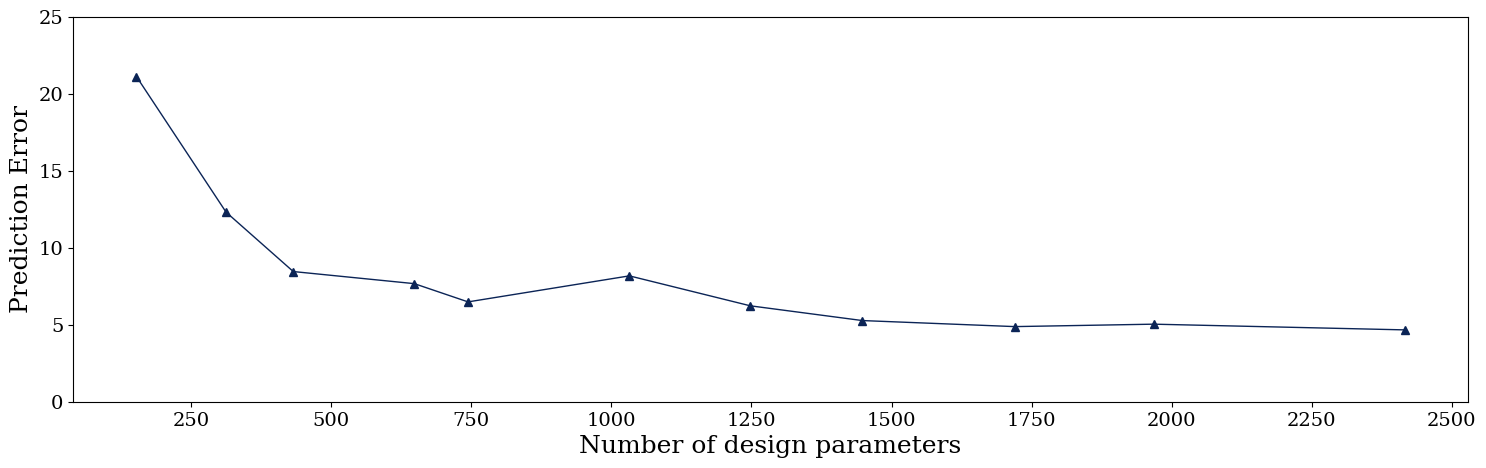

In [77]:
from matplotlib.ticker import MaxNLocator

# mean_init_pred_error = jnp.mean(jnp.array(init_pred_err_all), axis=1)
# print(mean_init_pred_error.shape)

# mean_opt_pred_error = jnp.mean(jnp.array(opt_pred_err_all), axis=1)
# print(mean_opt_pred_error.shape)

# improvement = jnp.array(improvement_all)
# print(improvement.shape)

x_label = jnp.array([10,13,15,18,20,23,25,27,30,32,35])
x_label_design_params = jnp.array(num_design_params)
color_list = ["#cc3f40", "#bdccd4", "#0b2456",]

N=6
# fig, ax1 = plt.subplots(figsize=(18, 5))
# ax1.plot(x_label, mean_init_pred_error, "-o", linewidth=1, label="Initial", color=color_list[1])
# ax1.plot(x_label, mean_opt_pred_error, "-^", linewidth=1, label="Optimized", color=color_list[2])
# ax1.set_xlabel("Size")
# ax1.set_ylabel("Prediction Error")
# # ax1.legend()
# ax2 = ax1.twinx()   
# ax2.plot(x_label, improvement_pred, "--s", linewidth=1, label="Improvement", color="k")
# # ax2.set_yscale("log")
# ax2.set_ylabel("Improvement")
# # ax2.legend()
# ax1.grid(False)
# ax2.grid(False)
# ax1.margins(x=0.05) 
# ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
# ax2.margins(x=0.05) 
# ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
# plt.xticks(x_label)
# plt.savefig(f"Figure/Circular_structure/structure_complexity/4_sensors_initial_vs_optimized_prediction_error_depending_on_size_2.png", dpi=300, bbox_inches="tight")
# plt.savefig(f"Figure/Circular_structure/structure_complexity/4_sensors_initial_vs_optimized_prediction_error_depending_on_size_2.eps")
# plt.show()


# fig, ax1 = plt.subplots(figsize=(18, 5))
# ax1.plot(x_label_design_params, mean_opt_pred_error, "-^", linewidth=1, label="Optimized", color=color_list[2])
# ax1.set_xlabel("Number of design parameters")
# ax1.set_ylabel("Prediction Error")
# ax1.set_ylim(0, 50.)
# ax1.legend()
# ax2 = ax1.twinx()   
# ax2.plot(x_label_design_params, improvement_pred, "--s", linewidth=1,  label="Improvement", color="k")
# ax2.set_yscale("log")
# ax2.set_ylabel("Improvement")
# ax2.set_ylim(0, 3.0)
# ax2.legend()
# ax1.grid(False)
# ax2.grid(False)
# ax1.margins(x=0.05) 
# ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
# ax2.margins(x=0.05) 
# ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
# plt.savefig(f"Figure/Circular_structure/structure_complexity/4_sensors_optimized_prediction_error_depending_on_design_params_2.png", dpi=300, bbox_inches="tight")
# plt.savefig(f"Figure/Circular_structure/structure_complexity/4_sensors_optimized_prediction_error_depending_on_design_params_2.eps")
# plt.show()

mean_opt_pred_error = jnp.mean(jnp.array(opt_pred_err_all), axis=1)

fig, ax1 = plt.subplots(figsize=(18, 5))
ax1.plot(x_label_design_params, mean_opt_pred_error, "-^", linewidth=1, label="Optimized", color=color_list[2])
ax1.set_xlabel("Number of design parameters")
ax1.set_ylabel("Prediction Error")
ax1.set_ylim(0, 25.)
# ax1.legend()
# ax2 = ax1.twinx()   
# ax2.plot(x_label_design_params, improvement_pred, "--s", linewidth=1,  label="Improvement", color="k")
# ax2.set_yscale("log")
# ax2.set_ylabel("Improvement")
# ax2.set_ylim(0, 3.0)
# ax2.legend()
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

import numpy as np

ticks = np.array([250,500,750,1000,1250,1500,1750,2000,2250,2500])

# ax1.set_xscale("log")

# # Set tick positions
ax1.set_xticks(ticks)

# # Format nicely (NOT scientific notation)
# ax1.set_xticklabels([str(int(t)) for t in ticks])

# # Optional: rotate to avoid overlap
# plt.setp(ax1.get_xticklabels(), rotation=30, ha='right')

# ax1.xaxis.set_major_locator(LogLocator(base=10.0))
# ax1.xaxis.set_major_formatter(LogFormatterSciNotation())
ax1.grid(False)
ax1.margins(x=0.05) 
# ax1.set_xscale("log")
# ax1.set_xticks(x_label_design_params)
# ax1.set_xticklabels(x_label_design_params)
# ax1.set_xticklabels([f"{int(x):,}" for x in x_label_design_params])
plt.savefig(f"Figure/Circular_structure/structure_complexity/4_sensors_optimized_prediction_error_increase_tests_org.png", dpi=300, bbox_inches="tight")
plt.savefig(f"Figure/Circular_structure/structure_complexity/4_sensors_optimized_prediction_error_increase_tests_org.eps")
plt.show()



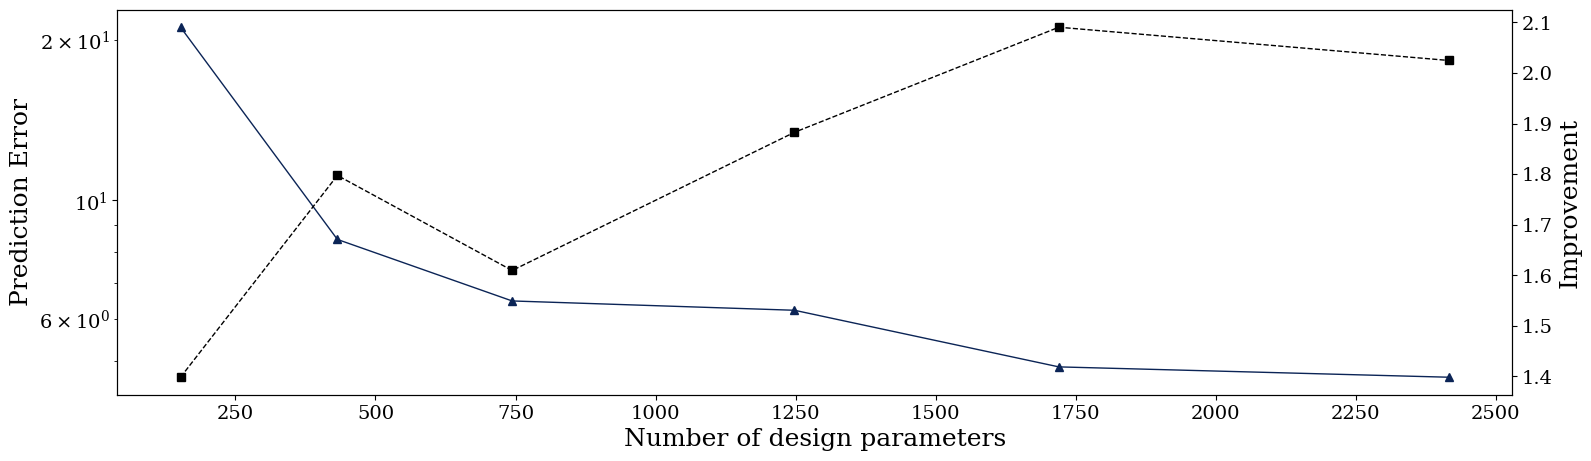

In [87]:
fig, ax1 = plt.subplots(figsize=(18, 5))
# ax1.plot(x_label_design_params, mean_init_pred_error, "-o", linewidth=1, label="Initial", color=color_list[1])
ax1.plot(x_label_design_params, mean_opt_pred_error, "-^", linewidth=1, label="Optimized", color=color_list[2])
ax1.set_xlabel("Number of design parameters")
ax1.set_ylabel("Prediction Error")
# ax1.set_ylim(0, 50.)
# ax1.legend()
ax1.set_yscale("log")
ax2 = ax1.twinx()   
ax2.plot(x_label_design_params, improvement_pred, "--s", linewidth=1,  label="Improvement", color="k")
# ax2.set_yscale("log")
ax2.set_ylabel("Improvement")
# ax2.set_ylim(0, 3.0)
# ax2.legend()
ax1.grid(False)
ax2.grid(False)
ax1.margins(x=0.05) 
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.margins(x=0.05) 
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
# ax1.set_xscale("log")
plt.savefig(f"Figure/Circular_structure/structure_complexity/4_sensors_initial_vs_optimized_prediction_error_depending_on_design_params_ylog.png", dpi=300, bbox_inches="tight")
plt.savefig(f"Figure/Circular_structure/structure_complexity/4_sensors_initial_vs_optimized_prediction_error_depending_on_design_params_ylog.eps")
plt.show()

In [57]:
num_design_params = []
for size, mids in SIZE_GENERAL_RUNS:
    measure_idx = jnp.array(mids)
    set_size_general_geometry(size)

    # Bonds between inner blocks
    horizontal_bonds = jnp.array([
        [geometry.n1_blocks * n2 * 4 + n1 * 4, geometry.n1_blocks * n2 * 4 + (n1 + 1) * 4 + 2]
        for n2 in range(geometry.n2_blocks) for n1 in range(geometry.n1_blocks - 1)
    ])
    vertical_bonds = jnp.array([
        [geometry.n1_blocks * n2 * 4 + n1 * 4 + 1, geometry.n1_blocks * (n2 + 1) * 4 + n1 * 4 + 1 + 2]
        for n2 in range(geometry.n2_blocks - 1) for n1 in range(geometry.n1_blocks)
    ])
    bonds = jnp.concatenate([horizontal_bonds, vertical_bonds], axis=0)

    # --- Map node indices to block indices ---
    def bond_to_block(bond):
        return bond // 4  # 4 nodes per block

    bond_blocks = vmap(bond_to_block)(bonds)
    b0 = bond_blocks[:, 0]
    b1 = bond_blocks[:, 1]

    print("number of quads : ", geometry.n_quads)
    all_params = 2 * 4 * geometry.n_quads # each quad has 4 nodes and 2 design parameters (horizontal and vertical shifts)
    print("number of design parameters without bonds : ", all_params )

    # --- Keep only bonds between inner blocks ---
    b0_inside = jnp.isin(b0, geometry.blocks_inside)
    b1_inside = jnp.isin(b1, geometry.blocks_inside)
    keep_mask = jnp.logical_and(b0_inside, b1_inside)
    filtered_bonds = bonds[keep_mask]
    print(filtered_bonds.shape)
    # print(filtered_bonds[:10])

    # --- Count bonds between inner blocks ---
    n_bonds = filtered_bonds.shape[0]
    print(f"Number of bonds between inner blocks: {n_bonds}")

    num_design_params.append(all_params - n_bonds * 2)
    print( "number of design parameters : ", num_design_params[-1] )

    

bias :  4.671744573825513
number of quads :  32
number of design parameters without bonds :  256
(52, 2)
Number of bonds between inner blocks: 52
number of design parameters :  152
bias :  2.3396295802023985
number of quads :  69
number of design parameters without bonds :  552
(120, 2)
Number of bonds between inner blocks: 120
number of design parameters :  312
bias :  5.756915592243518
number of quads :  97
number of design parameters without bonds :  776
(172, 2)
Number of bonds between inner blocks: 172
number of design parameters :  432
bias :  -0.42731868184825844
number of quads :  148
number of design parameters without bonds :  1184
(268, 2)
Number of bonds between inner blocks: 268
number of design parameters :  648
bias :  2.1119893837233357
number of quads :  172
number of design parameters without bonds :  1376
(316, 2)
Number of bonds between inner blocks: 316
number of design parameters :  744
bias :  1.2217105322024628
number of quads :  241
number of design parameters 

bias :  3.2349099925865876
size 25x25 | measure_idx (67, 75, 217, 225)
  dataset: /home/kna35/GaTech Dropbox/Kyungmi Na/physical-intelligence-change/notebooks/012326_circular_structure_dataset_n_source_8_exp_param_size_25.pickle
  coopt:   /home/kna35/GaTech Dropbox/Kyungmi Na/physical-intelligence-change/notebooks/04082026_circular_structure_cooptimization_n_source_16_size_25_measure_idx_67_75_217_225.pickle


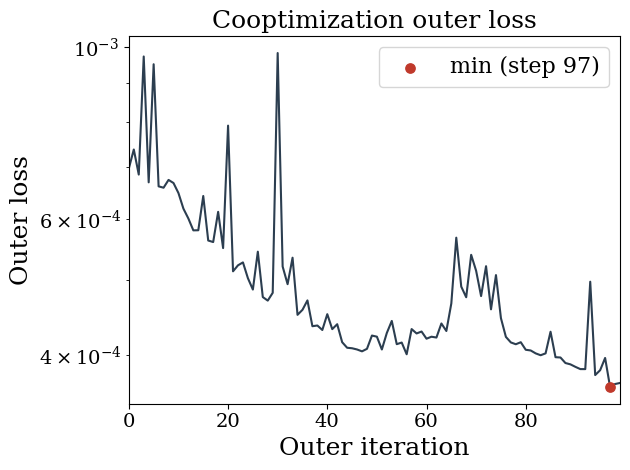

initial loss: 6.9763e-04
best loss: 3.6417e-04


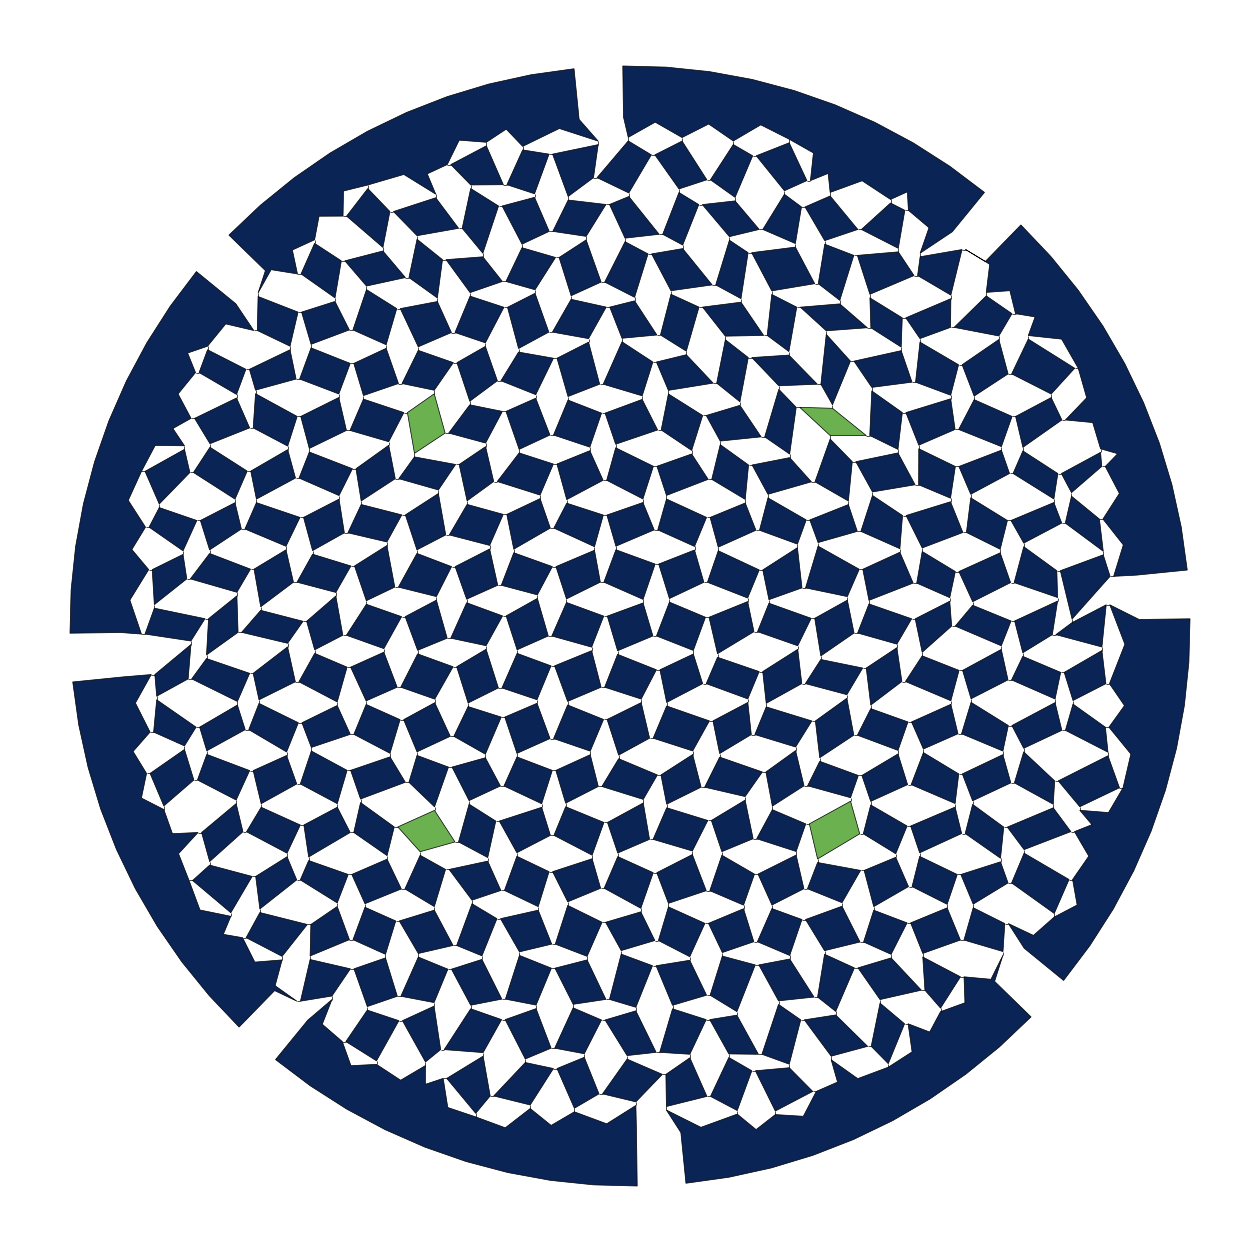

(1, 1, 12) (1, 1, 12)
(1, 1, 8) (1, 1, 8)
data min :  [[[-2.84681435e+03 -2.78477108e+03 -1.01181570e+00 -2.85368902e+03
   -3.08360918e+03 -1.35737951e+00 -2.67934850e+03 -1.90813606e+03
   -1.01436337e+00 -2.25978074e+03 -2.20341195e+03 -1.07912432e+00]]]
data max :  [[[2.10479206e+03 2.17924736e+03 6.68681943e-01 3.21850696e+03
   2.63365606e+03 7.63082365e-01 2.60305583e+03 2.60422086e+03
   7.75937569e-01 2.56919117e+03 2.99786242e+03 7.83396508e-01]]]
test data min :  [[[-1.60358077 -1.58009485 -1.60788117 -1.60656839 -1.60676801
   -1.59578997 -1.60946323 -1.58958608]]]
test data max :  [[[-0. -0. -0. -0. -0. -0. -0. -0.]]]
max, min of normailized force :  1.0 0.0
Initial training loss : 6.1340e-04
Initial test loss : 6.9763e-04
Initial training loss in original scale : 1.5720e-03
Initial test loss in original scale : 1.7856e-03
--------------------------------
1.0 0.0
Optimized training loss : 3.8176e-04
Optimized test loss : 3.6417e-04
Optimized training loss in original scale

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


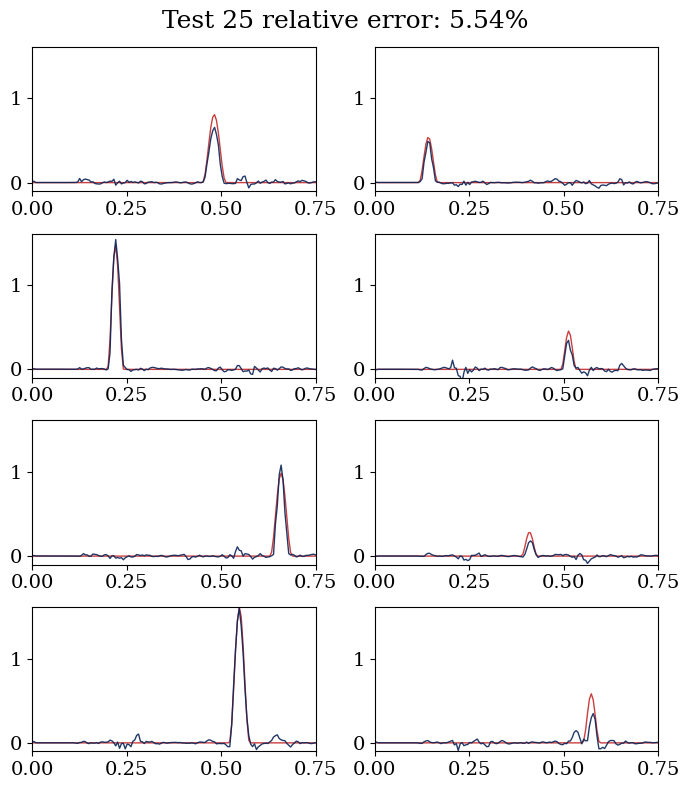

In [14]:
from pathlib import Path


# Directory where 112025_cooptimization_circular_structure_size_general.py writes pickles (often notebooks/).
NOTEBOOK_DIR = Path.cwd()


def set_size_general_geometry(size: int):
    """Rebuild globals to match 112025_cooptimization_circular_structure_size_general.py (n_piece=8)."""
    global n1_blocks, n2_blocks, n_piece, n_source, spacing, hinge_length, initial_angle
    global bond_length, simulation_time, n_timepoints, ts
    global horizontal_shifts, vertical_shifts, hori_shifts_length
    global geometry, block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors
    global _bond_connectivity, _reference_bond_vectors

    n1_blocks = int(size)
    n2_blocks = int(size)
    n_piece = 8
    n_source = n_piece * 2
    spacing = 15.0 + 0.075 * 15.0
    hinge_length = 0.075 * 15.0
    bond_length = hinge_length
    initial_angle = 25.0 * jnp.pi / 180.0
    simulation_time = 1.0
    n_timepoints = 200
    ts = jnp.linspace(0, simulation_time, n_timepoints)

    horizontal_shifts, vertical_shifts = QuadGeometry_Circle_InputSource(
        n1_blocks, n2_blocks, spacing=spacing, bond_length=hinge_length, n_piece=n_piece
    ).get_design_from_rotated_square(angle=initial_angle)

    hori_shifts_length = (n1_blocks + 1) * n2_blocks * 2

    geometry = QuadGeometry_Circle_InputSource_vis(
        n1_blocks=n1_blocks,
        n2_blocks=n2_blocks,
        spacing=spacing,
        bond_length=bond_length,
        n_piece=n_piece,
        n_outer=10
    )
    block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors = geometry.get_parametrization()
    _bond_connectivity = bond_connectivity()
    _reference_bond_vectors = reference_bond_vectors(horizontal_shifts, vertical_shifts)


def resolve_dataset_pickle_size_general(size: int, search_dir=None):
    d = search_dir or NOTEBOOK_DIR
    candidates = [
        d / f"012326_circular_structure_dataset_n_source_8_exp_param_size_{size}.pickle",
        # d / f"040226_circular_structure_dataset_n_source_8_size_{size}.pickle",
    ]
    for p in candidates:
        if p.is_file():
            return p
    raise FileNotFoundError(
        f"No dataset pickle for size={size} in {d}. Tried: " + ", ".join(str(c.name) for c in candidates)
    )


def resolve_coopt_pickle_size_general(size: int, measure_idx, search_dir=None):
    """Latest matching cooptimization result (date prefix varies by run)."""
    d = search_dir or NOTEBOOK_DIR
    tag = "_".join(str(int(i)) for i in measure_idx)
    pat = f"*circular_structure_cooptimization_n_source_16_size_{size}_measure_idx_{tag}.pickle"
    matches = sorted(d.glob(pat))
    if not matches:
        raise FileNotFoundError(f"No file matching {pat!r} under {d}")
    return matches[-1]


# Match your CLI runs: --size and --measure-idx
# SIZE_GENERAL_RUNS = [
#     (10, (5, 8, 17, 20)),
#     (15, (14, 18, 78, 82)),
#     (20, (33, 40, 117, 124)),
#     (25, (67, 75, 217, 225)),
#     (30, (79, 88, 298, 307)),
#     (35, (150, 162, 414, 426))
# ]

# SIZE_GENERAL_RUNS = [
#     (13, (14, 18, 41, 45)),
#     (18, (37, 42, 105, 110)),
#     (23, (50, 56, 168, 174)),
#     (27, (66, 74, 247, 255)),
#     (32, (100, 110, 358, 368))
# ]

SIZE_GENERAL_RUNS = [
    # (10, (5, 8, 17, 20)),
    # (13, (14, 18, 41, 45)),
    # (15, (14, 18, 78, 82)),
    # (18, (37, 42, 105, 110)),
    # (20, (33, 40, 117, 124)),
    # (23, (50, 56, 168, 174)),
    (25, (67, 75, 217, 225)),
    # (27, (66, 74, 247, 255)),
    # (30, (79, 88, 298, 307)),
    # (32, (100, 110, 358, 368)),
    # (35, (150, 162, 414, 426))
]


def visualize_all_size_general_runs(prediction=False, save_fig=False, search_dir=None):
    """Run visualize_data for each (size, sensors) after refreshing geometry globals."""
    init_pred_err_all = []
    opt_pred_err_all = []
    improvement_all = []
    for size, mids in SIZE_GENERAL_RUNS:
        measure_idx = jnp.array(mids)
        set_size_general_geometry(size)
        data_p = resolve_dataset_pickle_size_general(size, search_dir=search_dir)
        coopt_p = resolve_coopt_pickle_size_general(size, mids, search_dir=search_dir)
        print("=" * 72)
        print(f"size {size}x{size} | measure_idx {mids}")
        print(f"  dataset: {data_p}")
        print(f"  coopt:   {coopt_p}")

        init_prediction_error, opt_prediction_error, improvement = visualize_data(str(data_p), str(coopt_p), measure_idx, size=size, prediction=prediction, save_fig=save_fig)

        init_pred_err_all.append(init_prediction_error)
        opt_pred_err_all.append(opt_prediction_error)
        improvement_all.append(improvement)
    return init_pred_err_all, opt_pred_err_all, improvement_all

init_pred_err_all, opt_pred_err_all, improvement_all = visualize_all_size_general_runs(prediction=True, save_fig=True)  # set prediction=True for CNN vs. true plots
# _,_,_ = visualize_all_size_general_runs(prediction=False, save_fig=False)  # set prediction=True for CNN vs. true plots

In [32]:
# print("mean_init_pred_error : ", mean_init_pred_error)
# print("mean_opt_pred_error : ", mean_opt_pred_error)
print("improvement : ", improvement_all)


improvement :  [Array(0.71215339, dtype=float64), Array(0.55017988, dtype=float64), Array(0.61788682, dtype=float64), Array(0.52276106, dtype=float64), Array(0.47257207, dtype=float64), Array(0.48311271, dtype=float64)]


(6,)
(6,)
(6,)


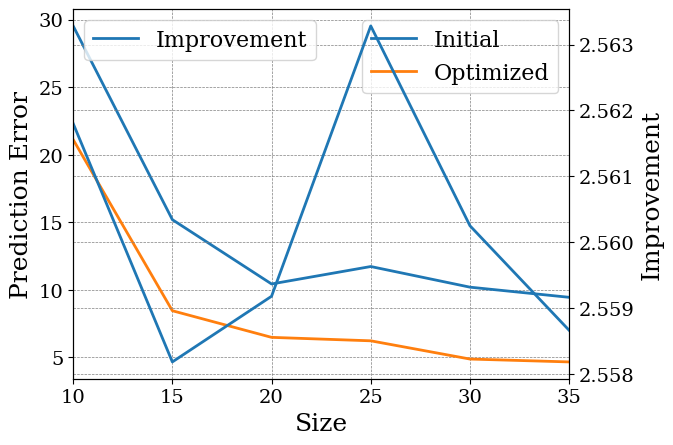

In [20]:
mean_init_pred_error = jnp.mean(jnp.array(init_pred_err_all), axis=1)
print(mean_init_pred_error.shape)

mean_opt_pred_error = jnp.mean(jnp.array(opt_pred_err_all), axis=1)
print(mean_opt_pred_error.shape)

improvement = jnp.array(improvement_all)
print(improvement.shape)

x_label = jnp.array([10, 15, 20, 25, 30, 35])

fig, ax1 = plt.subplots()
ax1.plot(x_label, mean_init_pred_error, label="Initial")
ax1.plot(x_label, mean_opt_pred_error, label="Optimized")
ax1.set_xlabel("Size")
ax1.set_ylabel("Prediction Error")
ax1.legend()
ax2 = ax1.twinx()   
ax2.plot(x_label, improvement, label="Improvement")
ax2.set_ylabel("Improvement")
ax2.legend()
plt.show()


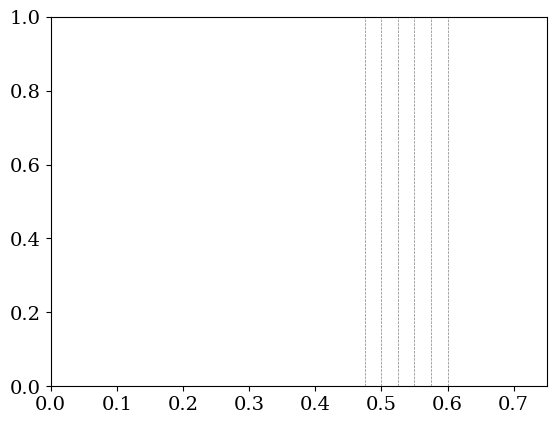

In [18]:

temp=jnp.array([0.475,0.500,0.525,0.550,0.575,0.600])
for i in range(len(temp)):
    plt.axvline(temp[i], linestyle="--", color="gray", linewidth=0.5)
plt.xlim([0.0, 0.75])
plt.savefig("Figure/time_line.eps")
plt.show()


data size :  (300, 200, 12)
data size :  (300, 200, 8)
(1, 1, 12) (1, 1, 12)
(1, 1, 8) (1, 1, 8)
Step: 0  Loss: 1.0378671495111453
Step : 0  Loss : 0.5985535352916604 Test Loss : 0.6012696302908662
Step : 10  Loss : 0.027412644302659706 Test Loss : 0.02499729752785002
Step : 20  Loss : 0.028969853183630764 Test Loss : 0.0279374223953739
Step : 30  Loss : 0.021006859958407786 Test Loss : 0.020359976089666523
Step : 40  Loss : 0.017175280842694367 Test Loss : 0.01646683526419059
Step : 50  Loss : 0.013260831357993372 Test Loss : 0.012567486835525556
Step : 60  Loss : 0.011220859640770665 Test Loss : 0.010627434417437057
Step : 70  Loss : 0.009523820452547564 Test Loss : 0.009040662037201825
Step : 80  Loss : 0.008243208921822653 Test Loss : 0.007848945139084705
Step : 90  Loss : 0.007181207575516949 Test Loss : 0.0069245659416627145
Step : 100  Loss : 0.006235354902804475 Test Loss : 0.006020355772485871
Step : 110  Loss : 0.0053654090037680464 Test Loss : 0.005201785475180448
Step : 120

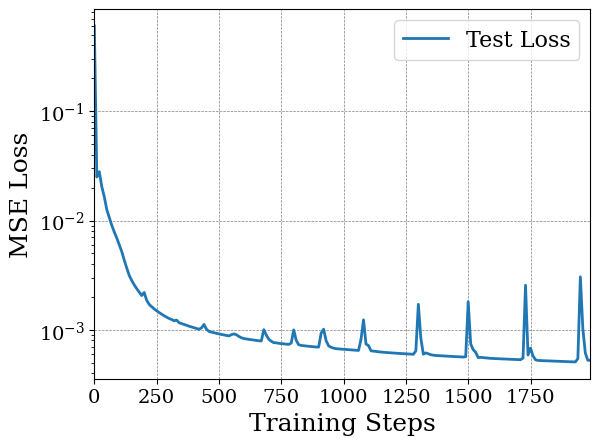

minimum train loss : 3.992e-04
minimum test loss : 5.095e-04


In [9]:
# training neural networks
size= 25
# n2_blocks = 25

with open(f"012326_circular_structure_dataset_n_source_8_exp_param_size_{size}.pickle", "rb") as f:
    data_dict = pickle.load(f)

# measure_idx = jnp.array([35, 73, 95, 122, 150,185, 200, 240])
# measure_idx = jnp.array([35, 57, 95, 122, 145, 189, 198, 240])
# input_data = jnp.zeros_like(data_dict["input_data"][:,:,2,measure_idx,:].squeeze()) # (N, time_steps, 3)
# input_data = input_data.at[:,:,:,0:2].set(data_dict["input_data"][:,:,2,measure_idx,0:2].squeeze()) # (N, time_steps, 2)
# input_data = input_data.at[:,:,:,2].set(data_dict["input_data"][:,:,1,measure_idx,2].squeeze()) # (N, time_steps, 2)
# N = input_data.shape[0]
# input_data = input_data.reshape((N, n_timepoints, -1))
input_data = data_dict['input_data']
output_data = data_dict['output_data']

key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])

mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

print("data size : ", input_data.shape)
print("data size : ", output_data.shape)

mm_scaler = minmax_scaler(training_input_data, training_output_data)
train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

def inner_loss(params, data, print_training, i):
    # print("inner loss")
    inputs, targets = data

    predictions = model.apply(params, inputs)
    mse = jnp.mean((predictions - targets)**2)  # this is L(phi_prime, D^{tr}_i)
    def print_fn():
        jax.debug.print("Step: {i}  Loss: {loss_val}", i=i, loss_val=mse)

    # if print_training=True, print the loss every 5 steps
    jax.lax.cond((jnp.mod(i, 5) == 0) & print_training, print_fn, lambda: None)
    return mse

solver = OptaxSolver(opt=optax.adam(1e-2),
                    fun=inner_loss,
                    maxiter=5000,
                    implicit_diff=True,
                    implicit_diff_solve=Partial(
                    linear_solve.solve_cg,
                    maxiter=20,
                    tol=1e-7),)
model = TimeSeriesCNN(output_features=8)

init_params = model.init(key, input_data)
preds = model.apply(init_params, input_data)
params = init_params
opt_state = solver.init_state(init_params, (train_data_normalized, train_output_normalized), True, i=0)

train_loss_record = []
test_loss_record = []
params_record = []

for i in range(2000):
    params, opt_state = solver.update(params, opt_state, (train_data_normalized, train_output_normalized), False, i)
    if i % 10 == 0:
        predictions = model.apply(params,train_data_normalized)
        predictions_test = model.apply(params, test_data_normalized)
        train_loss = jnp.mean((predictions - train_output_normalized)**2)
        test_loss = jnp.mean((predictions_test - test_output_normalized)**2)

        train_loss_record.append(train_loss)
        test_loss_record.append(test_loss)
        params_record.append(params)
        print(f"Step : {i}  Loss : {train_loss} Test Loss : {test_loss}")

# Plot loss
plt.figure()
plt.plot(jnp.arange(len(test_loss_record))*10, test_loss_record, label="Test Loss")
plt.xlabel("Training Steps")
plt.ylabel("MSE Loss")
plt.yscale("log")
plt.legend()
plt.show()

print(f"minimum train loss : {jnp.min(jnp.array(train_loss_record)):.3e}" )
print(f"minimum test loss : {jnp.min(jnp.array(test_loss_record)):.3e}" )

In [21]:
def show_results_multi_size(
    size_runs=None,
    N=4,
    reference_run=0,
    save_fig=False,
    folder="Circular_structure/size_comparison",
    name="",
    timeseries_view="peak",
    peak_half_width=20,
    show_initial=False,
    cmap_name="viridis",
    show_diff=False,
):
    """Compare NN force predictions across structural sizes on shared force data.

    Since the force output data (output_data) is identical across all structural
    sizes — only the structural response (input) differs — a single black "True"
    curve is the shared ground truth for every size.  Each size's prediction is
    colored by a gradient colormap so you can compare prediction quality across
    sizes at a glance.

    Creates one figure per test sample index (0 … N-1).  Each figure has
    n_piece//2 × 2 subplots (one per force channel).

    Parameters
    ----------
    size_runs : list of (size, measure_idx) tuples
        Defaults to SIZE_GENERAL_RUNS.
    N : int
        Number of test samples to visualize.
    reference_run : int
        Index into size_runs whose test_output_data is used as the "True" curve
        and for computing peak-window indices.
    save_fig : bool
        Save .eps and .png to Figure/{folder}/.
    folder : str
        Subdirectory under Figure/ for saved figures.
    name : str
        Optional prefix for figure titles and filenames.
    timeseries_view : str
        "peak"  — zoom each channel to [peak - peak_half_width, peak + peak_half_width].
        "full"  — plot the entire time axis.
    peak_half_width : int
        Half-width in time steps for the peak window.
    show_initial : bool
        If True, also overlay the initial (pre-optimisation) NN prediction as a
        dashed line in the same gradient colour (alpha 0.35).
    cmap_name : str
        Matplotlib colormap name, e.g. "viridis", "plasma", "coolwarm".
    show_diff : bool
        If True, produce a second figure per test sample showing
        (true − prediction) for each size, with a black zero line.
        Uses the same gradient colormap and time window as the main figure.
    """
    if size_runs is None:
        size_runs = SIZE_GENERAL_RUNS
    if reference_run < 0 or reference_run >= len(size_runs):
        raise ValueError("reference_run must be a valid index into size_runs")
    if timeseries_view not in ("peak", "full"):
        raise ValueError('timeseries_view must be "peak" or "full"')

    n_piece_local = 8
    n_sizes       = len(size_runs)
    sizes_only    = [s for s, _ in size_runs]

    cmap            = plt.get_cmap(cmap_name)
    gradient_colors = [cmap(i / max(n_sizes - 1, 1)) for i in range(n_sizes)]

    # ── Phase 1: load data and compute predictions for each size ─────────────
    runs = []
    for sk, (size, measure_idx) in enumerate(size_runs):
        set_size_general_geometry(size)   # updates globals: ts, n_piece, geometry, …
        print(f"\n[size {size}] loading …")

        data_filename  = resolve_dataset_pickle_size_general(size)
        coopt_filename = resolve_coopt_pickle_size_general(size, measure_idx)

        with open(data_filename, "rb") as f:
            data_dict = pickle.load(f)
        input_data  = data_dict["input_data"]
        output_data = data_dict["output_data"]

        with open(coopt_filename, "rb") as f:
            record_dict = pickle.load(f)
        loss_record    = jnp.array(record_dict["loss_record"])
        in_param_record = record_dict["nn_record"]
        best_loss_idx  = int(jnp.argmin(loss_record))
        print(f"[size {size}] best outer iter: {best_loss_idx}  "
              f"loss: {float(loss_record[best_loss_idx]):.4e}")

        # Recreate the same train / test split used during cooptimisation
        key     = random.PRNGKey(0)
        test_N  = input_data.shape[0] // 10
        test_idx_arr = jax.random.randint(
            key, shape=(test_N,), minval=0, maxval=input_data.shape[0])
        mask    = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx_arr].set(False)
        tr_in_full  = input_data[mask]
        tr_out_full = output_data[mask]

        mm_scaler = minmax_scaler(tr_in_full, tr_out_full)

        model = TimeSeriesCNN(output_features=n_piece_local)

        # ---------- initial NN ----------
        params_init = in_param_record[0][0]
        if size == 32:
            fname_i = (f"012326_circular_structure_dataset_n_source_8"
                       f"_exp_param_size_{size}_initial.pickle")
            with open(fname_i, "rb") as f:
                dd = pickle.load(f)
            te_in_i  = dd["input_data"][test_idx_arr]
            te_out_i = dd["output_data"][test_idx_arr]
        else:
            te_in_i  = in_param_record[0][4]
            te_out_i = in_param_record[0][5]

        te_in_i_norm, te_out_i_norm = mm_scaler.transform(te_in_i, te_out_i)
        pred_init_norm = model.apply(params_init, te_in_i_norm)
        _, pred_init_org = mm_scaler.inverse_transform(te_in_i_norm, pred_init_norm)
        mse_init = float(jnp.mean((pred_init_norm - te_out_i_norm) ** 2))
        print(f"[size {size}] initial test MSE (norm): {mse_init:.4e}")

        # ---------- optimised NN ----------
        params_opt = in_param_record[best_loss_idx][0]
        if size == 32:
            fname_o = (f"012326_circular_structure_dataset_n_source_8"
                       f"_exp_param_size_{size}_optimized.pickle")
            with open(fname_o, "rb") as f:
                dd = pickle.load(f)
            te_in_o  = dd["input_data"][test_idx_arr]
            te_out_o = dd["output_data"][test_idx_arr]
        else:
            te_in_o  = in_param_record[best_loss_idx][4]
            te_out_o = in_param_record[best_loss_idx][5]

        te_in_o_norm, te_out_o_norm = mm_scaler.transform(te_in_o, te_out_o)
        pred_opt_norm = model.apply(params_opt, te_in_o_norm)
        _, pred_opt_org = mm_scaler.inverse_transform(te_in_o_norm, pred_opt_norm)
        mse_opt     = float(jnp.mean((pred_opt_norm - te_out_o_norm) ** 2))
        mse_opt_org = float(jnp.mean((pred_opt_org  - te_out_o)      ** 2))
        print(f"[size {size}] optimised test MSE (norm): {mse_opt:.4e}  "
              f"(orig scale): {mse_opt_org:.4e}")

        runs.append({
            "size":            size,
            "test_output_data": te_out_o,     # shared ground-truth forces
            "pred_init_org":   pred_init_org,
            "pred_opt_org":    pred_opt_org,
            "color":           gradient_colors[sk],
        })

    # ── Phase 2: plotting ─────────────────────────────────────────────────────
    # After the loop, ts = linspace(0, 1, 200) (same for all sizes).
    ref      = runs[reference_run]["test_output_data"]
    view_tag = "full" if timeseries_view == "full" else f"peak_w{peak_half_width}"
    fig_w    = 11 if timeseries_view == "full" else 8

    for idx in jnp.arange(0, N, 1):
        idx_int = int(idx)

        # Per-channel peak indices from reference truth
        step_set = [int(jnp.argmax(-ref[idx_int, :, j])) for j in range(n_piece_local)]
        if timeseries_view == "peak":
            print(f"test {idx_int} peak indices:", step_set)

        fig, axes = plt.subplots(
            n_piece_local // 2, 2,
            figsize=(fig_w, 1.2 * n_piece_local))
        axes = axes.flatten()

        for j in range(n_piece_local):
            ax = axes[j]

            if timeseries_view == "full":
                sl   = slice(None)
                tseg = ts
            else:
                pk = step_set[j]
                pk = max(pk, peak_half_width)          # clamp left edge
                sl   = slice(pk - peak_half_width, pk + peak_half_width)
                tseg = ts[sl]

            # Shared ground-truth (black)
            ax.plot(tseg, -ref[idx_int, sl, j],
                    color="k", linewidth=0.9,
                    label="True" if j == 0 else None)

            # Each size's prediction colored by gradient
            for sk, run in enumerate(runs):
                c    = run["color"]
                size = run["size"]
                if show_initial:
                    ax.plot(tseg, -run["pred_init_org"][idx_int, sl, j],
                            color=c, alpha=0.35, linewidth=0.55, linestyle="--",
                            label=f"Size {size} (init)" if j == 0 else None)
                ax.plot(tseg, -run["pred_opt_org"][idx_int, sl, j],
                        color=c, alpha=0.92, linewidth=0.75,
                        label=f"Size {size}" if j == 0 else None)

            ax.set_ylabel(f"Channel {j + 1}")
            if j >= n_piece_local - 2:
                ax.set_xlabel("Time (s)")

        # Title: relative error per size
        err_parts = []
        for run in runs:
            truth = run["test_output_data"]
            pred  = run["pred_opt_org"]
            rel   = float(
                jnp.sum((truth[idx_int] - pred[idx_int]) ** 2)
                / jnp.sum(truth[idx_int] ** 2) * 100.0)
            err_parts.append(f"sz{run['size']}: {rel:.1f}%")
        title = f"{name}Test {idx_int} | {timeseries_view} | " + "  ".join(err_parts)
        plt.suptitle(title, fontsize=7)
        plt.tight_layout()

        # Legend from first subplot
        h, l = axes[0].get_legend_handles_labels()
        if h:
            fig.legend(h, l, loc="center left",
                       bbox_to_anchor=(1.01, 0.5), borderaxespad=0, fontsize=8)

        # Colorbar showing size → colour mapping
        sm = plt.cm.ScalarMappable(
            cmap=cmap_name,
            norm=plt.Normalize(vmin=sizes_only[0], vmax=sizes_only[-1]))
        sm.set_array([])
        cbar = fig.colorbar(
            sm, ax=axes.tolist(),
            location="right", pad=0.14, shrink=0.5, aspect=18)
        cbar.set_label("Structure size")
        cbar.set_ticks(sizes_only)

        plt.subplots_adjust(right=0.73)

        if save_fig:
            import os
            os.makedirs(f"Figure/{folder}", exist_ok=True)
            prefix = f"{name}_" if name else ""
            base   = (f"Figure/{folder}/{prefix}"
                      f"sim_multi_size_{view_tag}_test_{idx_int}_{cmap_name}")
            plt.savefig(f"{base}.eps", bbox_inches="tight")
            plt.savefig(f"{base}.png", bbox_inches="tight")
        plt.show()

        # ── optional difference figure ──────────────────────────────────────
        if show_diff:
            fig_d, axes_d = plt.subplots(
                n_piece_local // 2, 2,
                figsize=(fig_w, 1.2 * n_piece_local))
            axes_d = axes_d.flatten()

            for j in range(n_piece_local):
                ax = axes_d[j]

                if timeseries_view == "full":
                    sl   = slice(None)
                    tseg = ts
                else:
                    pk   = step_set[j]
                    pk   = max(pk, peak_half_width)
                    sl   = slice(pk - peak_half_width, pk + peak_half_width)
                    tseg = ts[sl]

                # zero reference
                ax.axhline(0.0, color="k", linewidth=0.7, linestyle="--")

                for sk, run in enumerate(runs):
                    c    = run["color"]
                    size = run["size"]
                    # diff = plotted_true − plotted_pred  (both already negated)
                    diff = ((-ref[idx_int, sl, j])
                            - (-run["pred_opt_org"][idx_int, sl, j]))
                    ax.plot(tseg, diff,
                            color=c, alpha=0.92, linewidth=0.75,
                            label=f"Size {size}" if j == 0 else None)

                ax.set_ylabel(f"Diff Ch {j + 1}")
                ax.set_ylim(-0.6, 0.6)
                if j >= n_piece_local - 2:
                    ax.set_xlabel("Time (s)")

            diff_title = f"{name}Test {idx_int} | difference (true − pred) | {timeseries_view}"
            plt.suptitle(diff_title, fontsize=8)
            plt.tight_layout()

            h_d, l_d = axes_d[0].get_legend_handles_labels()
            if h_d:
                fig_d.legend(h_d, l_d, loc="center left",
                             bbox_to_anchor=(1.01, 0.5), borderaxespad=0, fontsize=8)

            sm_d = plt.cm.ScalarMappable(
                cmap=cmap_name,
                norm=plt.Normalize(vmin=sizes_only[0], vmax=sizes_only[-1]))
            sm_d.set_array([])
            cbar_d = fig_d.colorbar(
                sm_d, ax=axes_d.tolist(),
                location="right", pad=0.14, shrink=0.5, aspect=18)
            cbar_d.set_label("Structure size")
            cbar_d.set_ticks(sizes_only)

            plt.subplots_adjust(right=0.73)

            if save_fig:
                base_d = (f"Figure/{folder}/{prefix}"
                          f"sim_multi_size_{view_tag}_test_{idx_int}_{cmap_name}_diff")
                plt.savefig(f"{base_d}.eps", bbox_inches="tight")
                plt.savefig(f"{base_d}.png", bbox_inches="tight")
            plt.show()


In [ ]:
SIZE_GENERAL_RUNS = [
    (10, (5, 8, 17, 20)),
    (13, (14, 18, 41, 45)),
    (15, (14, 18, 78, 82)),
    (18, (37, 42, 105, 110)),
    (20, (33, 40, 117, 124)),
    (23, (50, 56, 168, 174)),
    (25, (67, 75, 217, 225)),
    (27, (66, 74, 247, 255)),
    (30, (79, 88, 298, 307)),
    (32, (100, 110, 358, 368)),
    (35, (150, 162, 414, 426))
]

show_results_multi_size(
    size_runs=SIZE_GENERAL_RUNS,
    N=30,
    reference_run=0,
    save_fig=True,
    folder="Circular_structure/size_comparison",
    name="",
    timeseries_view="peak",
    peak_half_width=20,
    show_initial=False,
    cmap_name="viridis_r",
    show_diff=True,
)
